# AKI-Kohorte: Schweregrad-Scores & Interventionen-Timing

Kernnotebook für die Präsentation **„Critical Decisions in the ICU“**: AKI-Kohorte (10.485), Interventionen (Flüssigkeiten, Diuretika, Vasopressoren, Dialyse), Mortalität, Timing, SOFA/SAPS II, Chi², logistische Regression.

## Scores & Time Windows

| Score | Time Window | Source | Relevant For |
|-------|-------------|--------|--------------|
| **SOFA total** | First 24h | `mimiciii_derived.sofa` via `add_sofa_score()` | General ICU severity, case-mix |
| **SOFA renal** | First 24h | `mimiciii_derived.sofa` via `add_sofa_score()` | AKI organ-specific severity |
| **SAPS II** | First 24h | `mimiciii_derived.sapsii` via `add_sapsii_score()` | Mortality prediction, case-mix |
| **KDIGO (aki_stage)** | First 24h | Creatinine-based, computed in-notebook | AKI staging |

All scores are derived from the **first 24 hours** of the ICU stay (MIMIC-III first-day definition). When stratifying by intervention timing (e.g. vasopressor early vs. late), the 24h score window may overlap with the intervention period.

For shorter baseline windows (e.g. first 6h before any intervention) use `compute_sofa_from_raw(window_hours=6)` from `src/utils.py`.

### Präsentations-Grafiken (diese Code-Teile behalten)
- **§2** Kohorte laden & anreichern
- **§3** Interventionen-Übersicht → Balken „Interventions in AKI ICU Cohort“, „Hospital Mortality by Intervention Status“
- **Timing** → „Going even deeper“ (6 Plots: Mortality + Persistent RRT für Vasopressor/Fluid/Diuretic)
- **Severity** → „Within SOFA/SAPS II/SOFA renal groups: mortality by vasopressor timing“ (3 Plots)
- **Scores in Gruppen** → „SOFA 5–8“ und „SOFA 8–22: Severity scores by vasopressor timing“ (2 Plots)
- **Chi²** → Tabellen „Early vs Late“ und „Never vs Late“ (SOFA / SOFA renal bins)
- **Logit** → „Adjusted mortality by vasopressor timing“, „late vs never“, OR + Pseudo R²

**Exploratorisch (kann entfernt werden):** Effect Modification (Gender, Ethnicity), Subgruppen-Tabellen, zusätzliche Fluid/Diuretic-Timing-Plots nach Score-Bins, StratifiedTable-Tests.

In [65]:
# Optional: Einmal ausführen → erzeugt "07_saps2_presentation_only.ipynb" nur mit Code für die Präsentation
import json
from pathlib import Path
path = Path("07_saps2.ipynb")
with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)
keep_sigs = [
    "AKI-Kohorte", "Setup", "Kohorte laden", "load_aki_cohort", "add_sofa_score", "df_aki",
    "plot_interventions", "Interventions in AKI ICU Cohort", "Hospital Mortality by Intervention Status",
    "plot_mortality_by_intervention", "first_intervention_timing", "VASO_PATTERNS", "df3 = ",
    "mortality_by_timing", "mort_vaso", "Going even deeper", "Persistent RRT at ICU Discharge",
    "Within SOFA groups", "Within SAPS II", "Within SOFA renal", "SOFA 5–8", "SOFA 8–22",
    "Severity scores by vasopressor timing", "chi2_contingency", "Early vs Late", "Never vs Late",
    "smf.logit", "vaso_late", "Adjusted mortality", "hospital_mortality ~ vaso_late",
    "score_group_timing_stats", "plot_mortality_by_timing_within_score_bins",
    "test_late_vs_early", "test_never_vs_late", "df_test", "df_evle", "df_simple", "df_late_never",
]
def keep(c):
    src = "".join(c.get("source", []))
    if not src.strip() or "Optional: Einmal ausführen" in src:
        return False
    return any(s in src for s in keep_sigs)
nb["cells"] = [c for c in nb["cells"] if keep(c)]
out = path.parent / "07_saps2_presentation_only.ipynb"
with open(out, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=2, ensure_ascii=False)
print("Erstellt:", out)

Erstellt: 07_saps2_presentation_only.ipynb


## 1. Setup

## 2. Kohorte laden und anreichern
AKI-Kohorte aus `derived.mv_aki_icu_first_cohort`, SOFA/SAPS II, Dialyse-, Vasopressor-, Beatmungs- und Timing-Flags.

In [62]:
import sys
from pathlib import Path
import pandas as pd

# Projektwurzel = Ordner, in dem src/cohort.py liegt (von CWD aufwärts suchen)
_start = Path.cwd().resolve()
_project_root = None
for _p in [_start] + list(_start.parents):
    if (_p / "src" / "cohort.py").exists():
        _project_root = _p
        break
if _project_root is None:
    raise FileNotFoundError(
        f"Kein Ordner mit src/cohort.py gefunden (von {_start} aufwärts). "
        "Notebook aus dem Ordner report_abgabe öffnen oder CWD auf report_abgabe setzen."
    )
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))
PROJECT_ROOT = _project_root
print("Projektwurzel:", PROJECT_ROOT)

Projektwurzel: C:\Users\tobra\biomedical\mimiciii-BioMedicalProject\report_abgabe


In [63]:
# Projektwurzel = report_abgabe (dieses Notebook liegt in report_abgabe/nieren)
import sys
import importlib.util
from pathlib import Path

_start = Path.cwd().resolve()
_candidates = []
for _p in [_start] + list(_start.parents):
    if (_p / "src" / "cohort.py").exists():
        _candidates.append(_p)
if not _candidates and (_start / "report_abgabe" / "src" / "cohort.py").exists():
    _candidates.append(_start / "report_abgabe")
if not _candidates and (_start / "mimiciii-BioMedicalProject" / "report_abgabe" / "src" / "cohort.py").exists():
    _candidates.append(_start / "mimiciii-BioMedicalProject" / "report_abgabe")

_project_root = None
for _p in _candidates:
    if _p.name == "report_abgabe" or (_p / "nieren").is_dir():
        _project_root = _p
        break
if _project_root is None and _candidates:
    _project_root = _candidates[0]
if _project_root is None:
    raise FileNotFoundError("src/cohort.py nicht gefunden. Ordner 'report_abgabe' öffnen oder CWD auf report_abgabe setzen.")

_project_root = _project_root.resolve()
_sp = str(_project_root)
# Nur report_abgabe als Quelle für "src": andere Einträge mit src/cohort.py (z. B. Hauptprojekt) raus
sys.path = [_sp] + [p for p in sys.path if p != _sp and not (Path(p).resolve() / "src" / "cohort.py").exists()]
# Gecachtes "src" entfernen, damit neu von report_abgabe geladen wird
for _k in list(sys.modules.keys()):
    if _k == "src" or _k.startswith("src."):
        del sys.modules[_k]

# Paket "src" anlegen, damit "from src.db import q" in cohort/utils funktioniert
import types
_src = types.ModuleType("src")
_src.__path__ = [str(_project_root / "src")]
sys.modules["src"] = _src

def _load_src_module(name: str):
    path = _project_root / "src" / f"{name}.py"
    spec = importlib.util.spec_from_file_location(f"src.{name}", path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[f"src.{name}"] = mod
    setattr(sys.modules["src"], name, mod)
    spec.loader.exec_module(mod)
    return mod

_load_src_module("db")
_load_src_module("cohort")
_load_src_module("utils")
from src.cohort import load_aki_cohort
from src.utils import (
    add_icu_los_days,
    add_dialysis_flag,
    add_early_dopamine_flag,
    add_sofa_score,
    add_sapsii_score,
    add_vasopressor_flags,
    add_mechanical_ventilation_flag,
    add_early_late_dialysis_flags,
    extract_dialysis_timing,              # falls in src.utils vorhanden
    add_dialysis_near_icu_discharge_flag,
    recode_ethnicity,
    add_rrt_persistence_near_discharge,
)

# 1) Load cohort
df_aki = load_aki_cohort()

# 2) Ensure time columns are datetime (super wichtig!)
for c in ["intime", "outtime", "admittime", "dischtime", "deathtime"]:
    if c in df_aki.columns:
        df_aki[c] = df_aki[c].astype("datetime64[ns]")

# 3) Add baseline / outcomes
df_aki = add_icu_los_days(df_aki)

# 4) Dialysis "ever" flag (pragmatic; ICD + MV)
df_aki = add_dialysis_flag(df_aki)

# 5) SOFA + interventions
df_aki = add_sofa_score(df_aki)
df_aki = add_sapsii_score(df_aki)
df_aki = add_mechanical_ventilation_flag(df_aki)

# 6) Vasopressors / dopamine early flags
df_aki = add_vasopressor_flags(df_aki, window_hours=24)
df_aki = add_early_dopamine_flag(df_aki, window_hours=24)

# 7) Ethnicity grouping
df_aki = recode_ethnicity(df_aki)   # sollte eine neue Spalte wie ethnicity_grp erzeugen

# 8) Timing-aware dialysis (nur MV Events)
df_aki = add_early_late_dialysis_flags(
    df_aki,
    window_hours=24,
    include_inputevents=True,
    allow_negative_hours=False
)

# 9) Optional: Dialysis start/end/duration (falls du die Funktion hast)
# df_aki = extract_dialysis_timing(df_aki)

# 10) Dialysis near ICU discharge (last 6h)
df_aki = add_dialysis_near_icu_discharge_flag(
    df_aki,
    hours_before_discharge=6,
    include_inputevents=True
)
df_aki = extract_dialysis_timing(df_aki)
df_aki = add_rrt_persistence_near_discharge(
    df_aki,
    hours_before_discharge=6
) 

# 11) Quick sanity checks
print("Rows:", len(df_aki))


Rows: 10485


## 3. Interventionen-Übersicht
Häufigkeit der Interventionen (Dialyse, Vasopressoren, Beatmung, Fluids, Diuretika).

In [7]:
import pandas as pd

def intervention_summary(df, cols):
    out = []
    n = len(df)
    for c in cols:
        if c not in df.columns:
            continue
        s = df[c]
        # robust: falls bool/float/NaN
        x = pd.to_numeric(s, errors="coerce").fillna(0).astype(int)
        out.append({
            "variable": c,
            "n": int(x.sum()),
            "pct": float(x.mean() * 100),
            "missing": int(s.isna().sum()),
        })
    return pd.DataFrame(out).sort_values(["pct","n"], ascending=False)

cols_existing = [
    # dialysis
    "dialysis","dialysis_timed","early_dialysis","late_dialysis","dialysis_icd_only",
    "dialysis_last_6h","rrt_any_in_last6h","rrt_active_at_outtime","rrt_persistent_last6h",
    # ventilation
    "mechanical_ventilation",
    # vasopressors + dopamine
    "any_vasopressor","early_norepinephrine","early_epinephrine","early_phenylephrine","early_dopamine",
]

summary_existing = intervention_summary(df_aki, cols_existing)
print(summary_existing.to_string(index=False))


              variable    n       pct  missing
mechanical_ventilation 4969 47.391512        0
       any_vasopressor 1564 14.916547        0
              dialysis 1386 13.218884        0
  early_norepinephrine 1113 10.615165        0
   early_phenylephrine  796  7.591798        0
     dialysis_icd_only  781  7.448736        0
        dialysis_timed  609  5.808298        0
      dialysis_last_6h  465  4.434907        0
     rrt_any_in_last6h  465  4.434907        0
 rrt_persistent_last6h  441  4.206009        0
        early_dopamine  337  3.214115        0
         late_dialysis  324  3.090129        0
        early_dialysis  285  2.718169        0
     early_epinephrine  135  1.287554        0
 rrt_active_at_outtime   40  0.381497        0


### Fluids & Diuretika (Early-Flags)
Early = innerhalb der ersten 24 h (konfigurierbar).

In [8]:
from src.utils import (
    add_early_fluid_flag,
    add_early_diuretic_flag,
)

WINDOW_HOURS = 24  # <- hier anpassen (z.B. 6, 12, 24, 48)

df = df_aki.copy()
df = add_early_fluid_flag(df, window_hours=WINDOW_HOURS)
df = add_early_diuretic_flag(df, window_hours=WINDOW_HOURS)


KeyboardInterrupt: 

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_interventions(df, cols, title="Interventions", figsize=(9, 5)):
    """Horizontal bar chart: Anteil (n) pro Intervention (0/1)."""
    out = []
    for c in cols:
        if c not in df.columns:
            continue
        x = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)
        out.append({"variable": c.replace("_", " ").title(), "n": int(x.sum()), "pct": 100 * x.mean()})
    plot_df = pd.DataFrame(out).sort_values("pct", ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(plot_df))
    ax.barh(y, plot_df["pct"], color="steelblue", alpha=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["variable"])
    ax.set_xlabel("Anteil (%)")
    ax.set_title(title)
    for i, (_, row) in enumerate(plot_df.iterrows()):
        ax.text(row["pct"] + 0.5, i, f"n={row['n']}", va="center", fontsize=9)
    plt.tight_layout()
    return fig

### Balkendiagramm: Interventionen in der AKI-Kohorte

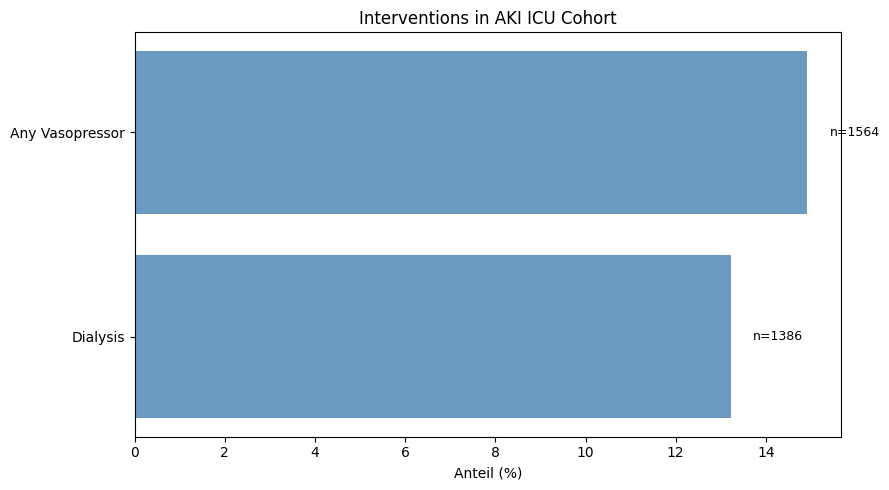

In [10]:
cols = [
    "dialysis",
    "any_vasopressor",
    "early_fluid",
    "any_fluid",
    "early_diuretic",
    "any_diuretic",
]

fig = plot_interventions(
    df,
    cols,
    title="Interventions in AKI ICU Cohort"
)
plt.show()


### Hospital Mortality by Intervention Status

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_mortality_by_intervention(
    df,
    interventions,
    mortality_col="hospital_mortality",
    figsize=(9, 5),
    title="Hospital Mortality by Intervention Status"
):
    rows = []

    for c in interventions:
        if c not in df.columns:
            continue

        for val, label in [(1, "Yes"), (0, "No")]:
            sub = df[df[c] == val]
            if len(sub) == 0:
                continue

            mort = pd.to_numeric(sub[mortality_col], errors="coerce")
            rows.append({
                "Intervention": c.replace("_", " ").title(),
                "Group": label,
                "Mortality": 100 * mort.mean(),
                "N": len(sub),
            })

    plot_df = pd.DataFrame(rows)

    # Order by mortality in YES group
    order = (
        plot_df[plot_df["Group"] == "Yes"]
        .sort_values("Mortality")["Intervention"]
    )

    fig, ax = plt.subplots(figsize=figsize)

    y = np.arange(len(order))
    width = 0.35

    yes = plot_df[plot_df["Group"] == "Yes"].set_index("Intervention").loc[order]
    no  = plot_df[plot_df["Group"] == "No"].set_index("Intervention").loc[order]

    ax.barh(y - width/2, no["Mortality"], height=width, label="No")
    ax.barh(y + width/2, yes["Mortality"], height=width, label="Yes")

    # --- Labels: % and n
    for i, name in enumerate(order):
        ax.text(
            no.loc[name, "Mortality"] + 0.6,
            i - width/2,
            f'{no.loc[name, "Mortality"]:.1f}%  (n={no.loc[name, "N"]})',
            va="center",
            fontsize=10
        )
        ax.text(
            yes.loc[name, "Mortality"] + 0.6,
            i + width/2,
            f'{yes.loc[name, "Mortality"]:.1f}%  (n={yes.loc[name, "N"]})',
            va="center",
            fontsize=10
        )

    ax.set_yticks(y)
    ax.set_yticklabels(order, fontsize=11)
    ax.set_xlabel("Hospital Mortality (%)", fontsize=12)
    ax.set_title(title, fontsize=14)

    ax.legend(frameon=False)
    ax.set_xlim(0, max(plot_df["Mortality"]) * 1.25)

    plt.tight_layout()
    return fig


In [12]:
df["early_vasopressor"] = (
    (df["early_norepinephrine"] == 1) |
    (df["early_epinephrine"] == 1) |
    (df["early_phenylephrine"] == 1)
).astype(int)
(df["early_vasopressor"] == df["any_vasopressor"]).all()


True

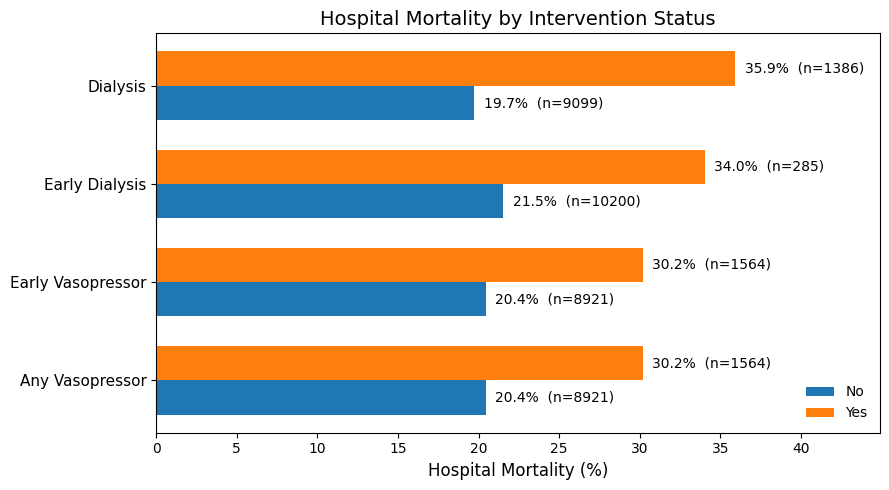

In [13]:
interventions = [
    "dialysis",
    "early_dialysis",
    "any_vasopressor",
    "early_vasopressor",
    "any_fluid",
    "early_fluid",
    "any_diuretic",
    "early_diuretic",

]

fig = plot_mortality_by_intervention(
    df,
    interventions,
    mortality_col="hospital_mortality",
    title="Hospital Mortality by Intervention Status"
)

plt.show()


In [14]:
import pandas as pd
import numpy as np
from src.db import q

def first_intervention_timing(
    df,
    patterns,
    label,
):
    """
    Adds two columns:
      - first_<label>_hours
      - first_<label>_timing  ∈ {0–12 h, 12–24 h, >24 h, No intervention}
    """

    where = " OR ".join([f"LOWER(di.label) LIKE '{p}'" for p in patterns])

    ev = q(f"""
        SELECT ie.icustay_id, ie.starttime
        FROM inputevents_mv ie
        JOIN d_items di ON ie.itemid = di.itemid
        WHERE {where}
    """)

    ev = ev.merge(
        df[["icustay_id", "intime"]],
        on="icustay_id",
        how="inner"
    ).dropna(subset=["starttime", "intime"])

    ev["hours_since_icu"] = (
        ev["starttime"] - ev["intime"]
    ).dt.total_seconds() / 3600

    ev = ev[ev["hours_since_icu"] >= 0]

    first_ev = (
        ev.sort_values(["icustay_id", "hours_since_icu"])
          .groupby("icustay_id", as_index=False)
          .first()[["icustay_id", "hours_since_icu"]]
    )

    out = df.merge(first_ev, on="icustay_id", how="left")

    timing_col = f"first_{label}_timing"
    hours_col = f"first_{label}_hours"

    out[hours_col] = out["hours_since_icu"]

    out[timing_col] = np.select(
        [
            out[hours_col].between(0, 12, inclusive="left"),
            out[hours_col].between(12, 24, inclusive="left"),
            out[hours_col] > 24,
            out[hours_col].isna(),
        ],
        [
            "0–12 h",
            "12–24 h",
            ">24 h",
            "No intervention",
        ],
        default="Other",
    )

    out[timing_col] = pd.Categorical(
        out[timing_col],
        categories=["0–12 h", "12–24 h", ">24 h", "No intervention"],
        ordered=True
    )

    return out.drop(columns=["hours_since_icu"])


In [16]:
VASO_PATTERNS = [
    "%norepinephrine%", "%epinephrine%",
    "%phenylephrine%", "%vasopressin%",
]

FLUID_PATTERNS = [
    "%normal saline%", "%0.9%saline%", "%saline%",
    "%lactated ring%", "%ringer%",
    "%plasmalyte%", "%plasma-lyte%",
    "%d5w%", "%dextrose%",
    "%albumin%",
    "%packed red%", "%prbc%", "%red blood cell%",
    "%fresh frozen plasma%", "%ffp%",
    "%platelet%",
]

DIURETIC_PATTERNS = [
    "%furosemide%", "%lasix%",
    "%bumetanide%", "%torsemide%",
    "%chlorothiazide%", "%metolazone%",
    "%mannitol%", "%acetazolamide%",
]


In [17]:
df3 = df.copy()

df3 = first_intervention_timing(df3, VASO_PATTERNS, "vaso")
df3 = first_intervention_timing(df3, FLUID_PATTERNS, "fluid")
df3 = first_intervention_timing(df3, DIURETIC_PATTERNS, "diuretic")


In [18]:
def mortality_by_timing(df, timing_col, mortality_col="hospital_mortality"):
    out = (
        df
        .groupby(timing_col)
        .agg(
            n=(mortality_col, "size"),
            mortality_pct=(mortality_col, "mean"),
        )
        .reset_index()
    )
    out["mortality_pct"] *= 100
    return out


In [19]:
mort_vaso = mortality_by_timing(df3, "first_vaso_timing")
mort_fluid = mortality_by_timing(df3, "first_fluid_timing")
mort_diur = mortality_by_timing(df3, "first_diuretic_timing")

mort_vaso, mort_fluid, mort_diur


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2454756539.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2454756539.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2454756539.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


(  first_vaso_timing     n  mortality_pct
 0            0–12 h  1419      29.668781
 1           12–24 h   148      35.135135
 2             >24 h   376      49.734043
 3   No intervention  8542      19.140716,
   first_fluid_timing     n  mortality_pct
 0             0–12 h  4291      21.090655
 1            12–24 h   323      15.170279
 2              >24 h   214      19.158879
 3    No intervention  5657      22.980378,
   first_diuretic_timing     n  mortality_pct
 0                0–12 h   690      19.710145
 1               12–24 h   427      15.690867
 2                 >24 h  1142      21.453590
 3       No intervention  8226      22.453197)

In [20]:
import matplotlib.pyplot as plt

def plot_combined_mortality_by_timing(
    df,
    timing_cols,
    titles,
    mortality_col="hospital_mortality",
    figsize=(12, 4),
):
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)

    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    for ax, timing_col, title in zip(axes, timing_cols, titles):
        tmp = (
            df
            .groupby(timing_col)
            .agg(
                n=(mortality_col, "size"),
                mort=(mortality_col, "mean"),
            )
            .reindex(order)
            .reset_index()
        )

        tmp["mort"] *= 100

        ax.bar(
            tmp[timing_col],
            tmp["mort"]
        )

        for i, row in tmp.iterrows():
            if pd.isna(row["mort"]):
                continue
            ax.text(
                i,
                row["mort"] + 0.8,
                f'{row["mort"]:.1f}%\n(n={int(row["n"])})',
                ha="center",
                va="bottom",
                fontsize=11
            )

        ax.set_title(title, fontsize=13)
        ax.set_xlabel("Timing of first intervention", fontsize=11)
        ax.tick_params(axis="x", labelrotation=0, labelsize=11)

    axes[0].set_ylabel("Hospital Mortality (%)", fontsize=12)
    axes[0].set_ylim(0, df[mortality_col].mean() * 200)

    fig.suptitle(
        "Hospital Mortality by Timing of First Intervention",
        fontsize=15,
        y=1.05
    )

    plt.tight_layout()
    return fig


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1303331525.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1303331525.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1303331525.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


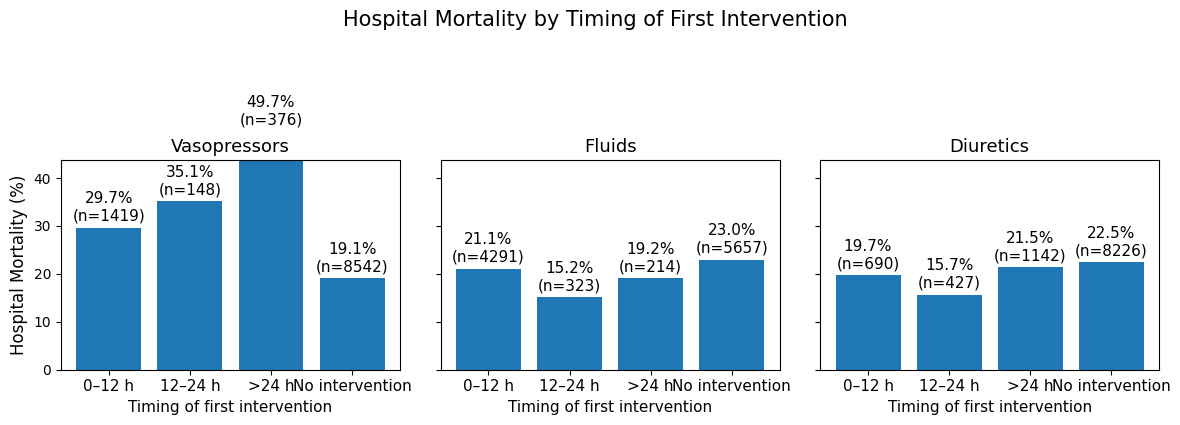

In [21]:
fig = plot_combined_mortality_by_timing(
    df3,
    timing_cols=[
        "first_vaso_timing",
        "first_fluid_timing",
        "first_diuretic_timing",
    ],
    titles=[
        "Vasopressors",
        "Fluids",
        "Diuretics",
    ],
)

plt.show()


In [22]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_mortality_by_timing_single(
    df,
    timing_col,
    title,
    mortality_col="hospital_mortality",
    colors=None,
    figsize=(4.5, 4),
):
    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    if colors is None:
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#7f7f7f"]

    tmp = (
        df
        .groupby(timing_col)
        .agg(
            n=(mortality_col, "size"),
            mort=(mortality_col, "mean"),
        )
        .reindex(order)
        .reset_index()
    )

    tmp["mort"] *= 100

    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        tmp[timing_col],
        tmp["mort"],
        color=colors
    )

    for i, row in tmp.iterrows():
        if pd.isna(row["mort"]):
            continue
        ax.text(
            i,
            row["mort"] + 0.8,
            f'{row["mort"]:.1f}%\n(n={int(row["n"])})',
            ha="center",
            va="bottom",
            fontsize=11
        )

    ax.set_ylabel("Hospital Mortality (%)", fontsize=12)
    ax.set_xlabel("Timing of first intervention", fontsize=11)
    ax.set_title(title, fontsize=14)

    ax.set_ylim(0, max(tmp["mort"].max() * 1.25, 5))
    ax.tick_params(axis="x", labelsize=11)

    plt.tight_layout()
    return fig


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\586205683.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


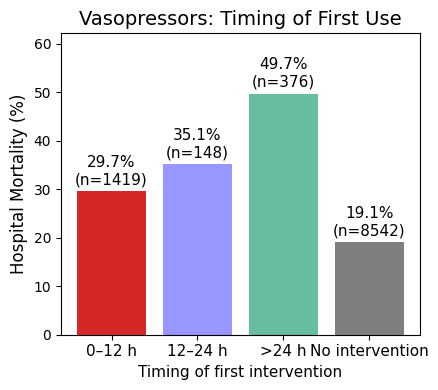

In [23]:
fig_vaso = plot_mortality_by_timing_single(
    df3,
    timing_col="first_vaso_timing",
    title="Vasopressors: Timing of First Use",
    colors=["#d62728", "#9896ff", "#67bda0", "#7f7f7f"],
)

plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\586205683.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


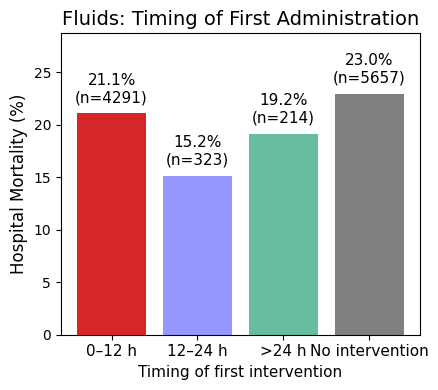

In [24]:
fig_fluid = plot_mortality_by_timing_single(
    df3,
    timing_col="first_fluid_timing",
    title="Fluids: Timing of First Administration",
    colors=["#d62728", "#9896ff", "#67bda0", "#7f7f7f"],
)

plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\586205683.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


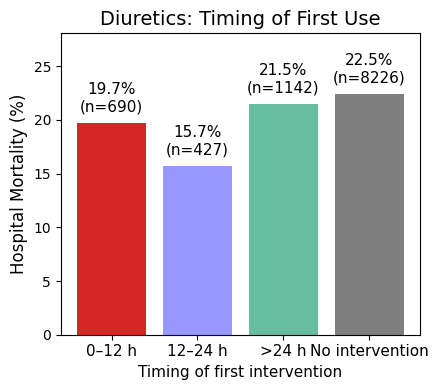

In [25]:
fig_diur = plot_mortality_by_timing_single(
    df3,
    timing_col="first_diuretic_timing",
    title="Diuretics: Timing of First Use",
    colors=["#d62728", "#9896ff", "#67bda0", "#7f7f7f"],
    
)

plt.show()


In [26]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_rrt_persistence_by_timing_single(
    df,
    timing_col,
    title,
    outcome_col="rrt_persistent_last6h",
    colors=None,
    figsize=(4.5, 4),
):
    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    if colors is None:
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#7f7f7f"]

    tmp = (
        df
        .groupby(timing_col)
        .agg(
            n=(outcome_col, "size"),
            rate=(outcome_col, "mean"),
        )
        .reindex(order)
        .reset_index()
    )

    tmp["rate"] *= 100

    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        tmp[timing_col],
        tmp["rate"],
        color=colors
    )

    for i, row in tmp.iterrows():
        if pd.isna(row["rate"]):
            continue
        ax.text(
            i,
            row["rate"] + 0.8,
            f'{row["rate"]:.1f}%\n(n={int(row["n"])})',
            ha="center",
            va="bottom",
            fontsize=11
        )

    ax.set_ylabel("Persistent RRT at ICU Discharge (%)", fontsize=12)
    ax.set_xlabel("Timing of first intervention", fontsize=11)
    ax.set_title(title, fontsize=14)

    ax.set_ylim(0, max(tmp["rate"].max() * 1.25, 5))
    ax.tick_params(axis="x", labelsize=11)

    plt.tight_layout()
    return fig


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\448871382.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


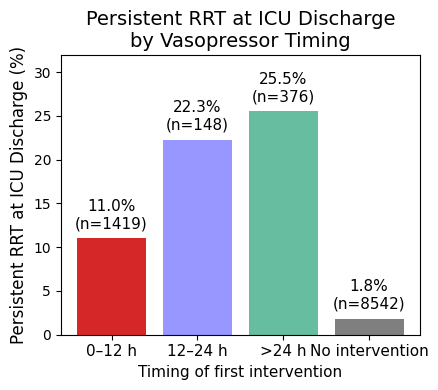

In [27]:
fig_vaso_rrt = plot_rrt_persistence_by_timing_single(
    df3,
    timing_col="first_vaso_timing",
    title="Persistent RRT at ICU Discharge\nby Vasopressor Timing",
    colors=["#d62728", "#9896ff", "#67bda0", "#7f7f7f"],
)
plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\448871382.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


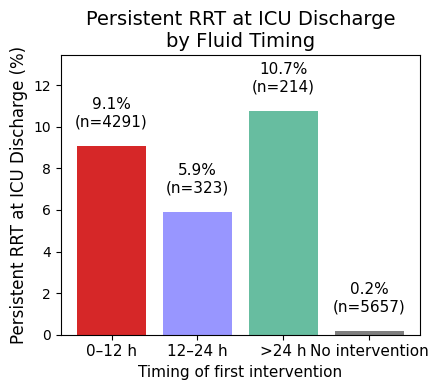

In [28]:
fig_fluid_rrt = plot_rrt_persistence_by_timing_single(
    df3,
    timing_col="first_fluid_timing",
    title="Persistent RRT at ICU Discharge\nby Fluid Timing",
    colors=["#d62728", "#9896ff", "#67bda0", "#7f7f7f"],
)

plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\448871382.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


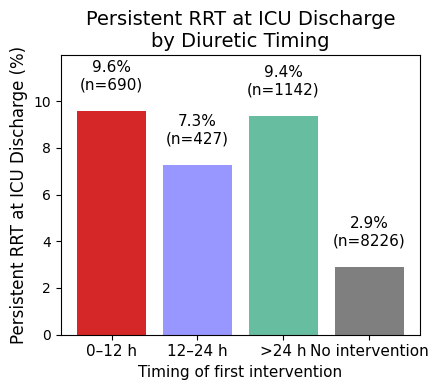

In [29]:
fig_diur_rrt = plot_rrt_persistence_by_timing_single(
    df3,
    timing_col="first_diuretic_timing",
    title="Persistent RRT at ICU Discharge\nby Diuretic Timing",
    colors=["#d62728", "#9896ff", "#67bda0", "#7f7f7f"],
)

plt.show()


In [31]:
import pandas as pd

def score_summary_by_timing(
    df,
    timing_col,
):
    out = (
        df
        .groupby(timing_col)
        .agg(
            n=("icustay_id", "size"),
            sofa_mean=("sofa", "mean"),
            sofa_sd=("sofa", "std"),
            sofa_renal_mean=("sofa_renal", "mean"),
            sofa_renal_sd=("sofa_renal", "std"),
            sapsii_mean=("sapsii", "mean"),
            sapsii_sd=("sapsii", "std"),
        )
        .reset_index()
    )

    out["SOFA total (mean ± SD)"] = out.apply(
        lambda r: f"{r['sofa_mean']:.1f} ± {r['sofa_sd']:.1f}", axis=1
    )
    out["SOFA renal (mean ± SD)"] = out.apply(
        lambda r: f"{r['sofa_renal_mean']:.1f} ± {r['sofa_renal_sd']:.1f}", axis=1
    )
    out["SAPS II (mean ± SD)"] = out.apply(
        lambda r: f"{r['sapsii_mean']:.1f} ± {r['sapsii_sd']:.1f}", axis=1
    )

    return out[
        [
            timing_col,
            "n",
            "SOFA total (mean ± SD)",
            "SOFA renal (mean ± SD)",
            "SAPS II (mean ± SD)",
        ]
    ]


In [32]:
scores_vaso = score_summary_by_timing(df3, "first_vaso_timing")
scores_fluid = score_summary_by_timing(df3, "first_fluid_timing")
scores_diur = score_summary_by_timing(df3, "first_diuretic_timing")

scores_vaso, scores_fluid, scores_diur



C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1783744738.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1783744738.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1783744738.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


(  first_vaso_timing     n SOFA total (mean ± SD) SOFA renal (mean ± SD)  \
 0            0–12 h  1419              9.0 ± 3.9              1.9 ± 1.3   
 1           12–24 h   148              9.2 ± 3.7              2.0 ± 1.4   
 2             >24 h   376              6.1 ± 3.3              1.6 ± 1.3   
 3   No intervention  8542              5.5 ± 3.3              1.7 ± 1.2   
 
   SAPS II (mean ± SD)  
 0         51.0 ± 16.1  
 1         53.4 ± 13.8  
 2         43.9 ± 13.8  
 3         40.9 ± 14.3  ,
   first_fluid_timing     n SOFA total (mean ± SD) SOFA renal (mean ± SD)  \
 0             0–12 h  4291              6.5 ± 3.8              1.7 ± 1.2   
 1            12–24 h   323              5.3 ± 2.9              1.7 ± 1.1   
 2              >24 h   214              4.8 ± 2.5              1.6 ± 1.2   
 3    No intervention  5657              5.9 ± 3.6              1.8 ± 1.2   
 
   SAPS II (mean ± SD)  
 0         43.7 ± 15.2  
 1         41.0 ± 13.0  
 2         38.4 ± 12.4  
 3   

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def plot_scores_by_timing(
    df,
    timing_col,
    title,
    figsize=(6.5, 4),
):
    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    tmp = (
        df
        .groupby(timing_col)
        .agg(
            n=("icustay_id", "size"),
            sofa=("sofa", "mean"),
            sofa_renal=("sofa_renal", "mean"),
            sapsii=("sapsii", "mean"),
        )
        .reindex(order)
        .reset_index()
    )

    x = np.arange(len(order))
    width = 0.25

    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(x - width, tmp["sofa"], width, label="SOFA total")
    ax.bar(x,         tmp["sofa_renal"], width, label="SOFA renal")
    ax.bar(x + width, tmp["sapsii"], width, label="SAPS II")

    for i, row in tmp.iterrows():
        ax.text(
            x[i],
            max(row["sofa"], row["sofa_renal"], row["sapsii"]) + 0.8,
            f"n={int(row['n'])}",
            ha="center",
            fontsize=10
        )

    ax.set_xticks(x)
    ax.set_xticklabels(order, fontsize=11)
    ax.set_ylabel("Mean score", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(frameon=False)

    plt.tight_layout()
    return fig


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\4245607479.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\4245607479.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\4245607479.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


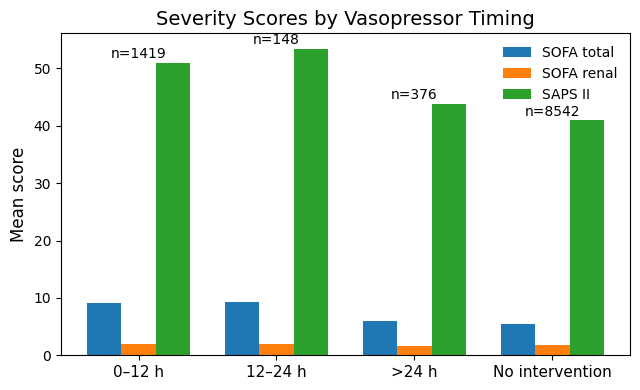

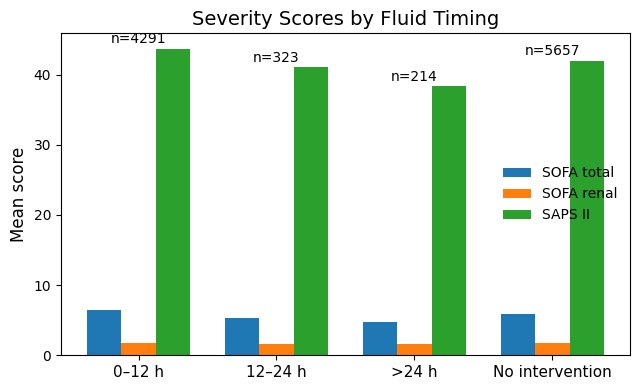

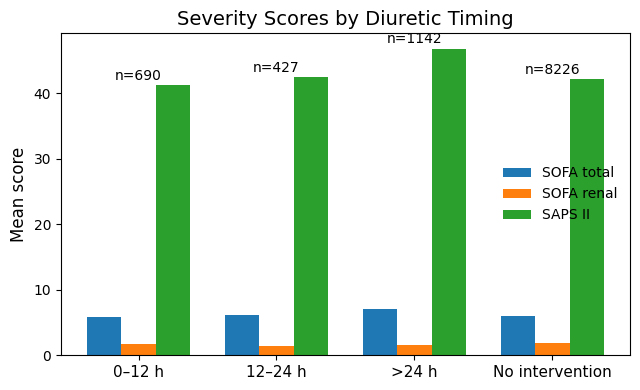

In [34]:
fig_vaso_scores = plot_scores_by_timing(
    df3,
    "first_vaso_timing",
    "Severity Scores by Vasopressor Timing",
)

fig_fluid_scores = plot_scores_by_timing(
    df3,
    "first_fluid_timing",
    "Severity Scores by Fluid Timing",
)

fig_diur_scores = plot_scores_by_timing(
    df3,
    "first_diuretic_timing",
    "Severity Scores by Diuretic Timing",
)

plt.show()


In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_score_by_timing(
    df,
    timing_col,
    score_col,
    title,
    ylabel,
    color="#1f77b4",
    figsize=(4.5, 4),
):
    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    tmp = (
        df
        .groupby(timing_col)
        .agg(
            n=("icustay_id", "size"),
            mean_score=(score_col, "mean"),
        )
        .reindex(order)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        tmp[timing_col],
        tmp["mean_score"],
        color=color,
    )

    for i, row in tmp.iterrows():
        if pd.isna(row["mean_score"]):
            continue
        ax.text(
            i,
            row["mean_score"] + 0.5,
            f'{row["mean_score"]:.1f}\n(n={int(row["n"])})',
            ha="center",
            va="bottom",
            fontsize=11
        )

    ax.set_title(title, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Timing of first intervention", fontsize=11)
    ax.tick_params(axis="x", labelsize=11)

    ax.set_ylim(0, max(tmp["mean_score"].max() * 1.25, 3))
    plt.tight_layout()
    return fig


In [36]:
def plot_mortality_by_timing(
    df,
    timing_col,
    title,
    mortality_col="hospital_mortality",
    color="#d62728",
    figsize=(4.5, 4),
):
    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    tmp = (
        df
        .groupby(timing_col)
        .agg(
            n=(mortality_col, "size"),
            mort=(mortality_col, "mean"),
        )
        .reindex(order)
        .reset_index()
    )

    tmp["mort"] *= 100

    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(
        tmp[timing_col],
        tmp["mort"],
        color=color,
    )

    for i, row in tmp.iterrows():
        if pd.isna(row["mort"]):
            continue
        ax.text(
            i,
            row["mort"] + 0.8,
            f'{row["mort"]:.1f}%\n(n={int(row["n"])})',
            ha="center",
            va="bottom",
            fontsize=11
        )

    ax.set_title(title, fontsize=14)
    ax.set_ylabel("Hospital Mortality (%)", fontsize=12)
    ax.set_xlabel("Timing of first intervention", fontsize=11)
    ax.tick_params(axis="x", labelsize=11)

    ax.set_ylim(0, max(tmp["mort"].max() * 1.25, 5))
    plt.tight_layout()
    return fig


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2917335501.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2917335501.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2917335501.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)
C:\Users\tobra\AppD

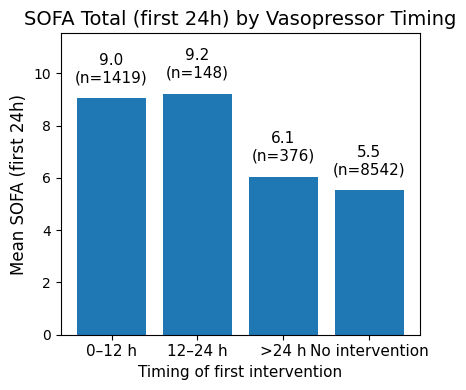

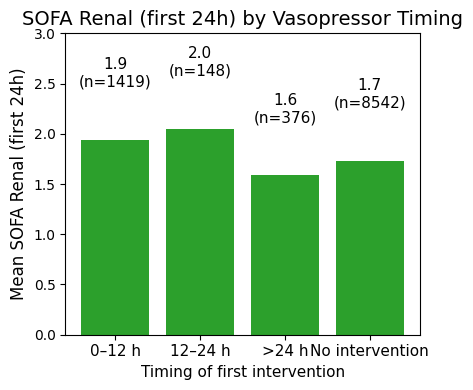

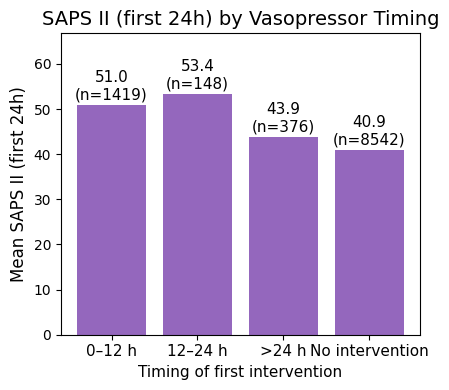

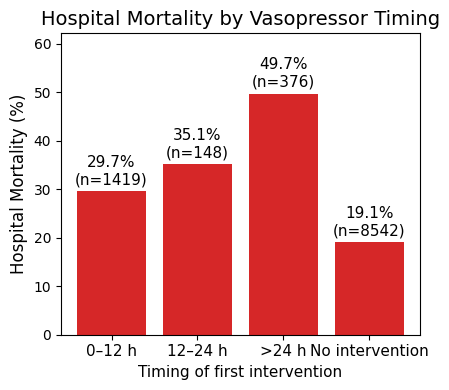

In [37]:
fig_sofa_vaso = plot_score_by_timing(
    df3,
    "first_vaso_timing",
    score_col="sofa",
    title="SOFA Total (first 24h) by Vasopressor Timing",
    ylabel="Mean SOFA (first 24h)",
    color="#1f77b4",
)

fig_sofa_renal_vaso = plot_score_by_timing(
    df3,
    "first_vaso_timing",
    score_col="sofa_renal",
    title="SOFA Renal (first 24h) by Vasopressor Timing",
    ylabel="Mean SOFA Renal (first 24h)",
    color="#2ca02c",
)

fig_saps_vaso = plot_score_by_timing(
    df3,
    "first_vaso_timing",
    score_col="sapsii",
    title="SAPS II (first 24h) by Vasopressor Timing",
    ylabel="Mean SAPS II (first 24h)",
    color="#9467bd",
)

fig_mort_vaso = plot_mortality_by_timing(
    df3,
    "first_vaso_timing",
    title="Hospital Mortality by Vasopressor Timing",
)

plt.show()


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_score_with_mortality_overlay(
    df,
    timing_col,
    score_col,
    mortality_col="hospital_mortality",
    title="",
    score_ylabel="Mean score",
    mort_ylabel="Hospital mortality (%)",
    score_color="#1f77b4",
    mort_color="#d62728",
    figsize=(5.2, 4),
):
    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    tmp = (
        df
        .groupby(timing_col)
        .agg(
            n=("icustay_id", "size"),
            score_mean=(score_col, "mean"),
            mort_mean=(mortality_col, "mean"),
        )
        .reindex(order)
        .reset_index()
    )

    tmp["mort_pct"] = tmp["mort_mean"] * 100

    x = np.arange(len(order))

    fig, ax1 = plt.subplots(figsize=figsize)

    # Bars = score
    ax1.bar(x, tmp["score_mean"], color=score_color, alpha=0.9)
    ax1.set_ylabel(score_ylabel, fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(order, fontsize=11)
    ax1.set_title(title, fontsize=14)

    # annotate score + n
    for i, row in tmp.iterrows():
        if pd.isna(row["score_mean"]):
            continue
        ax1.text(
            i,
            row["score_mean"] + (0.03 * tmp["score_mean"].max() if tmp["score_mean"].max() > 0 else 0.2),
            f'{row["score_mean"]:.1f}\n(n={int(row["n"])})',
            ha="center",
            va="bottom",
            fontsize=10
        )

    ax1.set_ylim(0, max(tmp["score_mean"].max() * 1.25, 1))

    # Line = mortality on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(x, tmp["mort_pct"], color=mort_color, marker="o", linewidth=2.5)
    ax2.set_ylabel(mort_ylabel, fontsize=12)

    for i, row in tmp.iterrows():
        if pd.isna(row["mort_pct"]):
            continue
        ax2.text(
            i,
            row["mort_pct"] + 0.8,
            f'{row["mort_pct"]:.1f}%',
            ha="center",
            va="bottom",
            fontsize=10,
            color=mort_color
        )

    ax2.set_ylim(0, max(tmp["mort_pct"].max() * 1.35, 5))

    plt.tight_layout()
    return fig


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\28006260.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


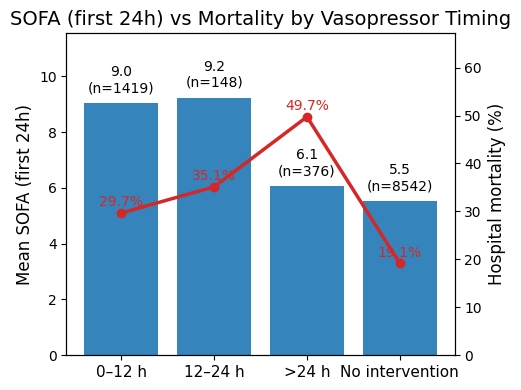

In [39]:
fig = plot_score_with_mortality_overlay(
    df3,
    timing_col="first_vaso_timing",
    score_col="sofa",
    title="SOFA (first 24h) vs Mortality by Vasopressor Timing",
    score_ylabel="Mean SOFA (first 24h)",
    mort_ylabel="Hospital mortality (%)",
    score_color="#1f77b4",
    mort_color="#d62728",
)
plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\28006260.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


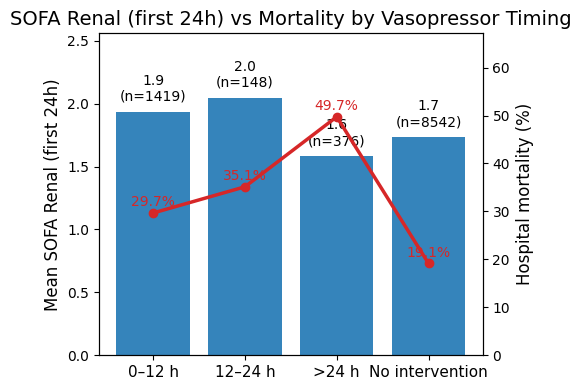

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\28006260.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


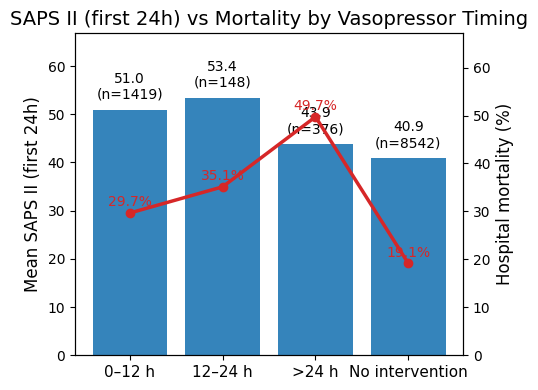

In [40]:
fig_sofa_renal = plot_score_with_mortality_overlay(
    df3,
    timing_col="first_vaso_timing",
    score_col="sofa_renal",
    title="SOFA Renal (first 24h) vs Mortality by Vasopressor Timing",
    score_ylabel="Mean SOFA Renal (first 24h)",
    mort_ylabel="Hospital mortality (%)",
    score_color="#1f77b4",
    mort_color="#d62728",
)
plt.show()

fig_saps = plot_score_with_mortality_overlay(
    df3,
    timing_col="first_vaso_timing",
    score_col="sapsii",
    title="SAPS II (first 24h) vs Mortality by Vasopressor Timing",
    score_ylabel="Mean SAPS II (first 24h)",
    mort_ylabel="Hospital mortality (%)",
    score_color="#1f77b4",
    mort_color="#d62728",
)
plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\28006260.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


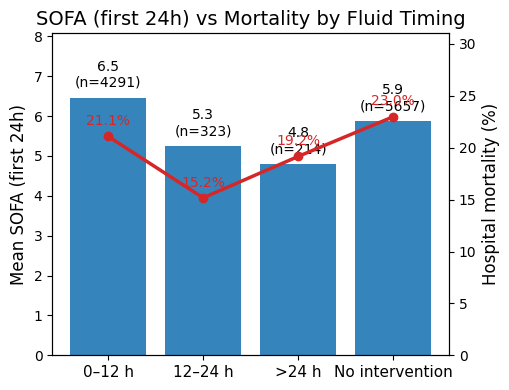

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\28006260.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


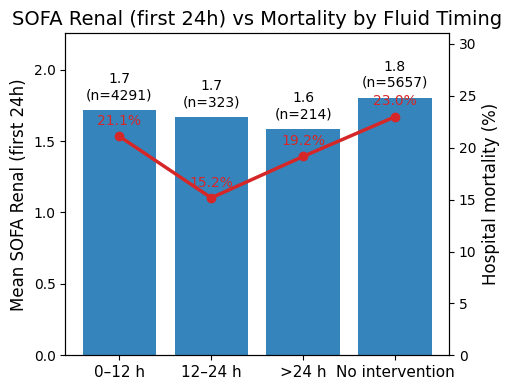

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\28006260.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


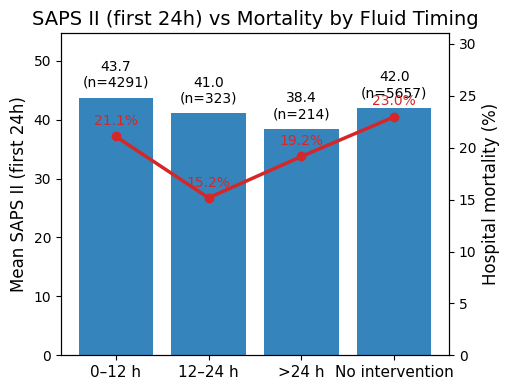

In [41]:
# Fluids — SOFA total + mortality
fig_fluid_sofa = plot_score_with_mortality_overlay(
    df3,
    timing_col="first_fluid_timing",
    score_col="sofa",
    title="SOFA (first 24h) vs Mortality by Fluid Timing",
    score_ylabel="Mean SOFA (first 24h)",
    score_color="#1f77b4",
    mort_color="#d62728",
)
plt.show()

# Fluids — SOFA renal + mortality
fig_fluid_renal = plot_score_with_mortality_overlay(
    df3,
    timing_col="first_fluid_timing",
    score_col="sofa_renal",
    title="SOFA Renal (first 24h) vs Mortality by Fluid Timing",
    score_ylabel="Mean SOFA Renal (first 24h)",
    score_color="#1f77b4",
    mort_color="#d62728",
)
plt.show()

# Fluids — SAPS II + mortality
fig_fluid_saps = plot_score_with_mortality_overlay(
    df3,
    timing_col="first_fluid_timing",
    score_col="sapsii",
    title="SAPS II (first 24h) vs Mortality by Fluid Timing",
    score_ylabel="Mean SAPS II (first 24h)",
    score_color="#1f77b4",
    mort_color="#d62728",
)
plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\28006260.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


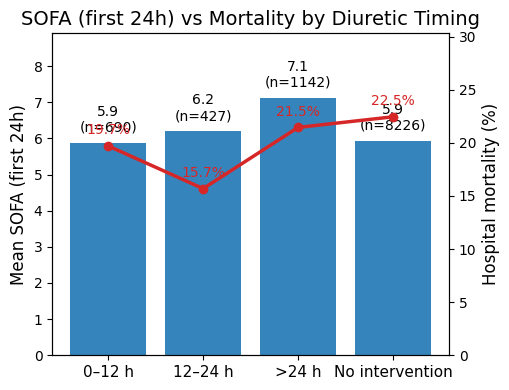

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\28006260.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


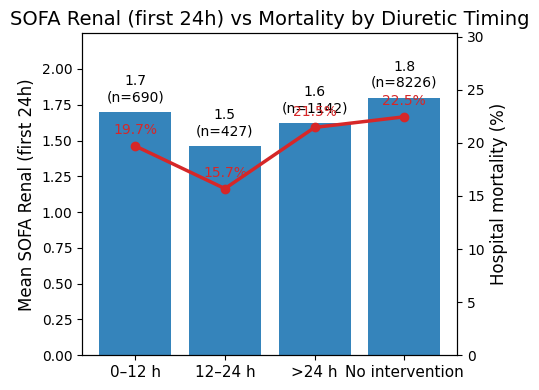

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\28006260.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


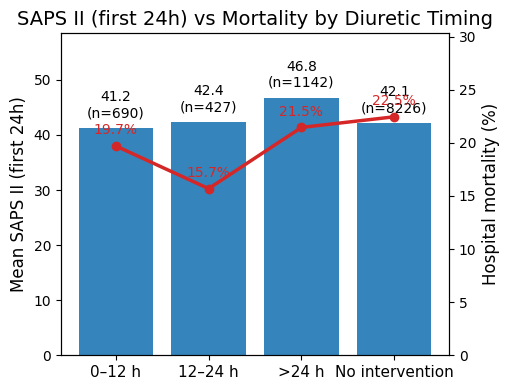

In [42]:
# Diuretics — SOFA total + mortality
fig_diur_sofa = plot_score_with_mortality_overlay(
    df3,
    timing_col="first_diuretic_timing",
    score_col="sofa",
    title="SOFA (first 24h) vs Mortality by Diuretic Timing",
    score_ylabel="Mean SOFA (first 24h)",
    score_color="#1f77b4",
    mort_color="#d62728",
)
plt.show()

# Diuretics — SOFA renal + mortality
fig_diur_renal = plot_score_with_mortality_overlay(
    df3,
    timing_col="first_diuretic_timing",
    score_col="sofa_renal",
    title="SOFA Renal (first 24h) vs Mortality by Diuretic Timing",
    score_ylabel="Mean SOFA Renal (first 24h)",
    score_color="#1f77b4",
    mort_color="#d62728",
)
plt.show()

# Diuretics — SAPS II + mortality
fig_diur_saps = plot_score_with_mortality_overlay(
    df3,
    timing_col="first_diuretic_timing",
    score_col="sapsii",
    title="SAPS II (first 24h) vs Mortality by Diuretic Timing",
    score_ylabel="Mean SAPS II (first 24h)",
    score_color="#1f77b4",
    mort_color="#d62728",
)
plt.show()


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_score_with_rrt_overlay(
    df,
    timing_col,
    score_col,
    outcome_col="rrt_persistent_last6h",
    title="",
    score_ylabel="Mean score",
    rrt_ylabel="Persistent RRT at ICU discharge (%)",
    score_color="#1f77b4",
    rrt_color="#d01515",
    figsize=(5.2, 4),
):
    order = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    tmp = (
        df
        .groupby(timing_col)
        .agg(
            n=("icustay_id", "size"),
            score_mean=(score_col, "mean"),
            rrt_mean=(outcome_col, "mean"),
        )
        .reindex(order)
        .reset_index()
    )

    tmp["rrt_pct"] = tmp["rrt_mean"] * 100
    x = np.arange(len(order))

    fig, ax1 = plt.subplots(figsize=figsize)

    # --- Bars: score
    ax1.bar(x, tmp["score_mean"], color=score_color, alpha=0.9)
    ax1.set_ylabel(score_ylabel, fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(order, fontsize=11)
    ax1.set_title(title, fontsize=14)

    for i, row in tmp.iterrows():
        if pd.isna(row["score_mean"]):
            continue
        ax1.text(
            i,
            row["score_mean"] + max(tmp["score_mean"].max() * 0.03, 0.2),
            f'{row["score_mean"]:.1f}\n(n={int(row["n"])})',
            ha="center",
            va="bottom",
            fontsize=10
        )

    ax1.set_ylim(0, max(tmp["score_mean"].max() * 1.25, 1))

    # --- Line: RRT persistence
    ax2 = ax1.twinx()
    ax2.plot(
        x,
        tmp["rrt_pct"],
        color=rrt_color,
        marker="o",
        linewidth=2.5
    )
    ax2.set_ylabel(rrt_ylabel, fontsize=12)

    for i, row in tmp.iterrows():
        if pd.isna(row["rrt_pct"]):
            continue
        ax2.text(
            i,
            row["rrt_pct"] + 0.8,
            f'{row["rrt_pct"]:.1f}%',
            ha="center",
            va="bottom",
            fontsize=10,
            color=rrt_color
        )

    ax2.set_ylim(0, max(tmp["rrt_pct"].max() * 1.35, 5))

    plt.tight_layout()
    return fig


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2149612300.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


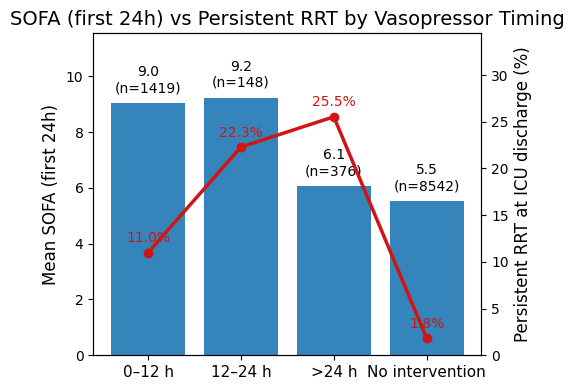

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2149612300.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


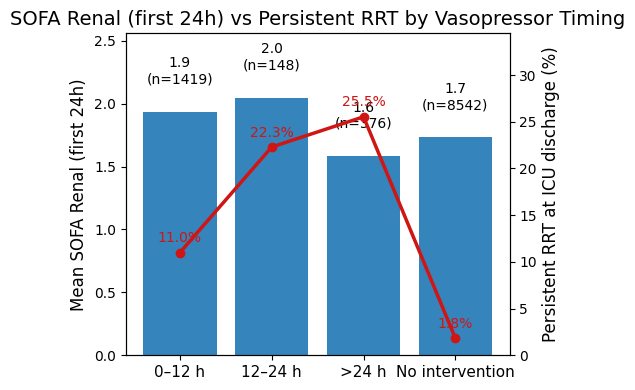

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2149612300.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


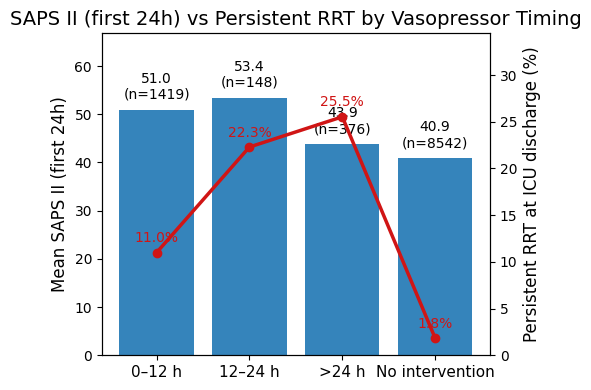

In [44]:
# SOFA total
plot_score_with_rrt_overlay(
    df3,
    timing_col="first_vaso_timing",
    score_col="sofa",
    title="SOFA (first 24h) vs Persistent RRT by Vasopressor Timing",
    score_ylabel="Mean SOFA (first 24h)",
    score_color="#1f77b4",
); plt.show()

# SOFA renal
plot_score_with_rrt_overlay(
    df3,
    timing_col="first_vaso_timing",
    score_col="sofa_renal",
    title="SOFA Renal (first 24h) vs Persistent RRT by Vasopressor Timing",
    score_ylabel="Mean SOFA Renal (first 24h)",
    score_color="#1f77b4",
); plt.show()

# SAPS II
plot_score_with_rrt_overlay(
    df3,
    timing_col="first_vaso_timing",
    score_col="sapsii",
    title="SAPS II (first 24h) vs Persistent RRT by Vasopressor Timing",
    score_ylabel="Mean SAPS II (first 24h)",
    score_color="#1f77b4", 
); plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2149612300.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


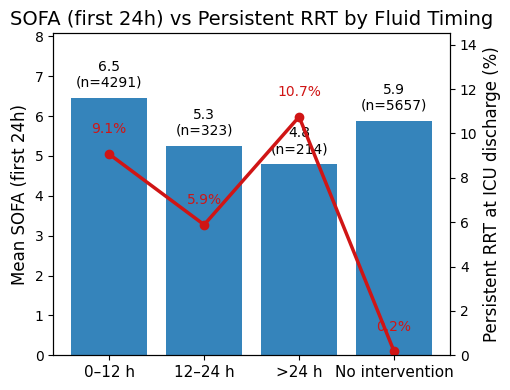

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2149612300.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


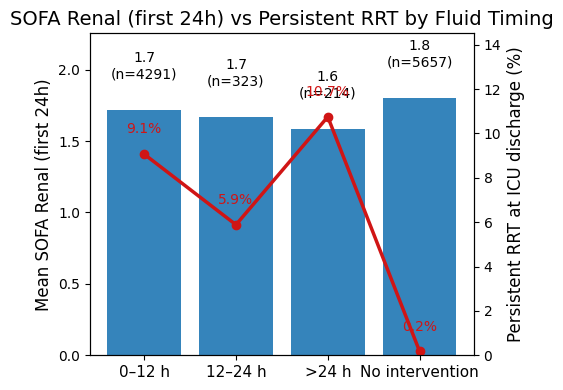

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2149612300.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


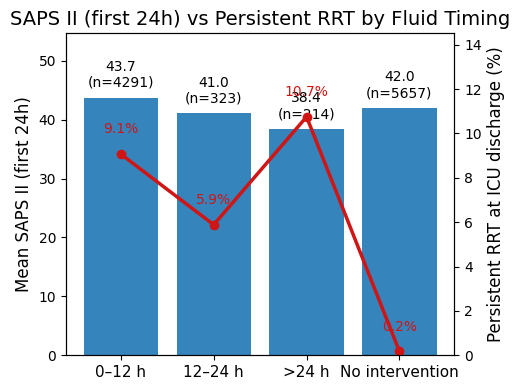

In [45]:
plot_score_with_rrt_overlay(
    df3,
    timing_col="first_fluid_timing",
    score_col="sofa",
    title="SOFA (first 24h) vs Persistent RRT by Fluid Timing",
    score_ylabel="Mean SOFA (first 24h)",
    score_color="#1f77b4",
); plt.show()

plot_score_with_rrt_overlay(
    df3,
    timing_col="first_fluid_timing",
    score_col="sofa_renal",
    title="SOFA Renal (first 24h) vs Persistent RRT by Fluid Timing",
    score_ylabel="Mean SOFA Renal (first 24h)",
    score_color="#1f77b4",
); plt.show()

plot_score_with_rrt_overlay(
    df3,
    timing_col="first_fluid_timing",
    score_col="sapsii",
    title="SAPS II (first 24h) vs Persistent RRT by Fluid Timing",
    score_ylabel="Mean SAPS II (first 24h)",
    score_color="#1f77b4",
); plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2149612300.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


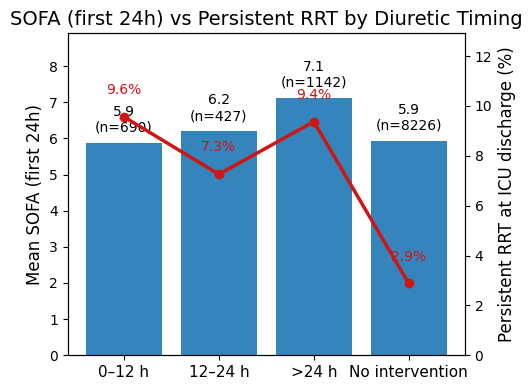

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2149612300.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


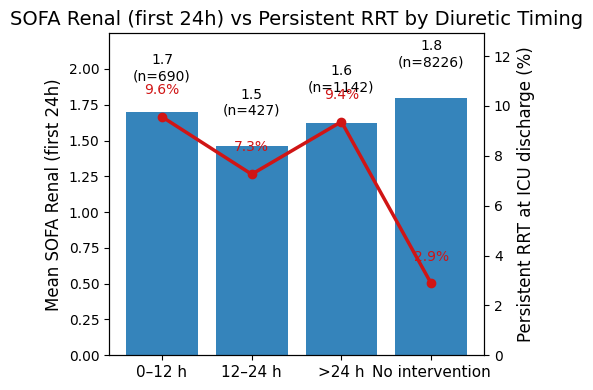

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\2149612300.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(timing_col)


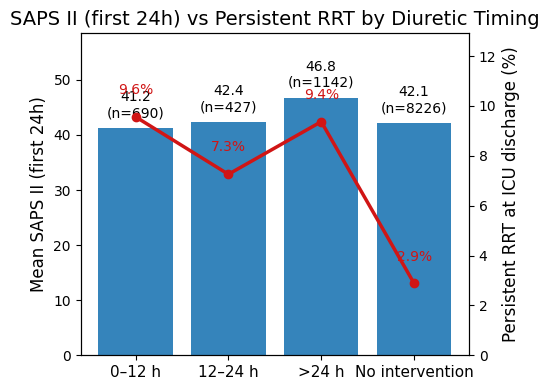

In [46]:
plot_score_with_rrt_overlay(
    df3,
    timing_col="first_diuretic_timing",
    score_col="sofa",
    title="SOFA (first 24h) vs Persistent RRT by Diuretic Timing",
    score_ylabel="Mean SOFA (first 24h)",
    score_color="#1f77b4",
); plt.show()

plot_score_with_rrt_overlay(
    df3,
    timing_col="first_diuretic_timing",
    score_col="sofa_renal",
    title="SOFA Renal (first 24h) vs Persistent RRT by Diuretic Timing",
    score_ylabel="Mean SOFA Renal (first 24h)",
    score_color="#1f77b4",
); plt.show()

plot_score_with_rrt_overlay(
    df3,
    timing_col="first_diuretic_timing",
    score_col="sapsii",
    title="SAPS II (first 24h) vs Persistent RRT by Diuretic Timing",
    score_ylabel="Mean SAPS II (first 24h)",
    score_color="#1f77b4",
); plt.show()


In [47]:
import pandas as pd
import numpy as np

def add_score_bins(df, score_col, n_bins=4, prefix=None):
    out = df.copy()
    if prefix is None:
        prefix = score_col

    # Quartile (robust, gleich große Gruppen)
    out[f"{prefix}_bin"] = pd.qcut(out[score_col], q=n_bins, duplicates="drop")
    return out

def hours_to_timing_group(hours_series):
    return pd.Categorical(
        np.select(
            [
                hours_series.between(0, 12, inclusive="left"),
                hours_series.between(12, 24, inclusive="left"),
                hours_series > 24,
                hours_series.isna(),
            ],
            ["0–12 h", "12–24 h", ">24 h", "No intervention"],
            default="Other",
        ),
        categories=["0–12 h", "12–24 h", ">24 h", "No intervention"],
        ordered=True
    )

# falls du nur *_timing hast, kannst du diesen Schritt überspringen
df4 = df3.copy()
df4["vaso_timing"] = hours_to_timing_group(df4.get("first_vaso_hours", np.nan))
df4["fluid_timing"] = hours_to_timing_group(df4.get("first_fluid_hours", np.nan))
df4["diuretic_timing"] = hours_to_timing_group(df4.get("first_diuretic_hours", np.nan))

# Score bins (Quartile) – du kannst auch n_bins=5 machen etc.
df4 = add_score_bins(df4, "sofa", n_bins=4, prefix="sofa")
df4 = add_score_bins(df4, "sofa_renal", n_bins=4, prefix="sofa_renal")
df4 = add_score_bins(df4, "sapsii", n_bins=4, prefix="sapsii")


In [48]:
def score_group_timing_stats(df, score_bin_col, timing_col, outcome_col="hospital_mortality"):
    # n und mortality pro Bin×Timing
    agg = (
        df.groupby([score_bin_col, timing_col])
          .agg(n=("icustay_id", "size"),
               mortality=(outcome_col, "mean"))
          .reset_index()
    )
    agg["mortality_pct"] = agg["mortality"] * 100

    # Timing-Verteilung innerhalb jedes Score-Bins
    agg["bin_total"] = agg.groupby(score_bin_col)["n"].transform("sum")
    agg["within_bin_pct"] = 100 * agg["n"] / agg["bin_total"]
    return agg

stats_sofa_vaso = score_group_timing_stats(df4, "sofa_bin", "vaso_timing")
stats_sofa_fluid = score_group_timing_stats(df4, "sofa_bin", "fluid_timing")
stats_sofa_diur = score_group_timing_stats(df4, "sofa_bin", "diuretic_timing")

stats_sofa_vaso.head()


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([score_bin_col, timing_col])
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg["bin_total"] = agg.groupby(score_bin_col)["n"].transform("sum")
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and 

,sofa_bin,vaso_timing,n,mortality,mortality_pct,bin_total,within_bin_pct
0,"(-0.001, 3.0]",0–12 h,76,0.105263,10.526316,2870,2.648084
1,"(-0.001, 3.0]",12–24 h,6,0.000000,0.000000,2870,0.209059
2,"(-0.001, 3.0]",>24 h,101,0.415842,41.584158,2870,3.519164
3,"(-0.001, 3.0]",No intervention,2687,0.086342,8.634164,2870,93.623693
4,"(3.0, 5.0]",0–12 h,183,0.131148,13.114754,2449,7.472438


In [49]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mortality_by_timing_within_score_bins(stats_df, score_bin_col, timing_col, title, figsize=(10, 4.5)):
    order_timing = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    bins = list(stats_df[score_bin_col].dropna().unique())
    bins = sorted(bins, key=lambda x: str(x))

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(bins))
    width = 0.2
    offsets = {"0–12 h": -1.5*width, "12–24 h": -0.5*width, ">24 h": 0.5*width, "No intervention": 1.5*width}

    for t in order_timing:
        sub = stats_df[stats_df[timing_col] == t].set_index(score_bin_col).reindex(bins)
        y = sub["mortality_pct"].values
        n = sub["n"].fillna(0).astype(int).values

        ax.bar(x + offsets[t], y, width, label=t)

        for i in range(len(bins)):
            if np.isnan(y[i]):
                continue
            # ax.text(x[i] + offsets[t], y[i] + 0.6, f"n={n[i]}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    labels = []
    for b in bins:
        n_bin = stats_df.loc[stats_df[score_bin_col] == b, "n"].sum()
        labels.append(f"{b}\n(n={int(n_bin)})")

    ax.set_xticklabels(labels, rotation=0, fontsize=10)
    ax.set_ylabel("Hospital mortality (%)", fontsize=12)
    ax.set_xlabel("Score group (quantiles)", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(frameon=False, ncol=4)
    ax.set_ylim(0, max(stats_df["mortality_pct"].max() * 1.25, 5))

    plt.tight_layout()
    return fig


In [50]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mortality_by_timing_within_score_bins(
    stats_df, score_bin_col, timing_col, title, figsize=(10, 4.5)
):
    order_timing = ["0–12 h", "12–24 h", ">24 h", "No intervention"]

    bins = list(stats_df[score_bin_col].dropna().unique())
    bins = sorted(bins, key=lambda x: str(x))

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(bins))
    width = 0.2
    offsets = {
        "0–12 h": -1.5 * width,
        "12–24 h": -0.5 * width,
        ">24 h": 0.5 * width,
        "No intervention": 1.5 * width,
    }

    for t in order_timing:
        sub = (
            stats_df[stats_df[timing_col] == t]
            .set_index(score_bin_col)
            .reindex(bins)
        )

        y = sub["mortality_pct"].values
        n = sub["n"].fillna(0).astype(int).values

        # Binomial standard error (in %)
        se = np.full_like(y, np.nan, dtype=float)
        valid = n > 0
        p = y[valid] / 100.0
        se[valid] = np.sqrt(p * (1 - p) / n[valid]) * 100

        ax.bar(
            x + offsets[t],
            y,
            width,
            label=t,
            yerr=se,
            capsize=3,
            error_kw=dict(lw=1, capthick=1),
        )

    ax.set_xticks(x)
    labels = []
    for b in bins:
        n_bin = stats_df.loc[stats_df[score_bin_col] == b, "n"].sum()
        labels.append(f"{b}\n(n={int(n_bin)})")

    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel("Hospital mortality (%)", fontsize=12)
    ax.set_xlabel("Score group (quantiles)", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(frameon=False, ncol=4)
    ax.set_ylim(0, max(stats_df["mortality_pct"].max() * 1.25, 5))

    plt.tight_layout()
    return fig


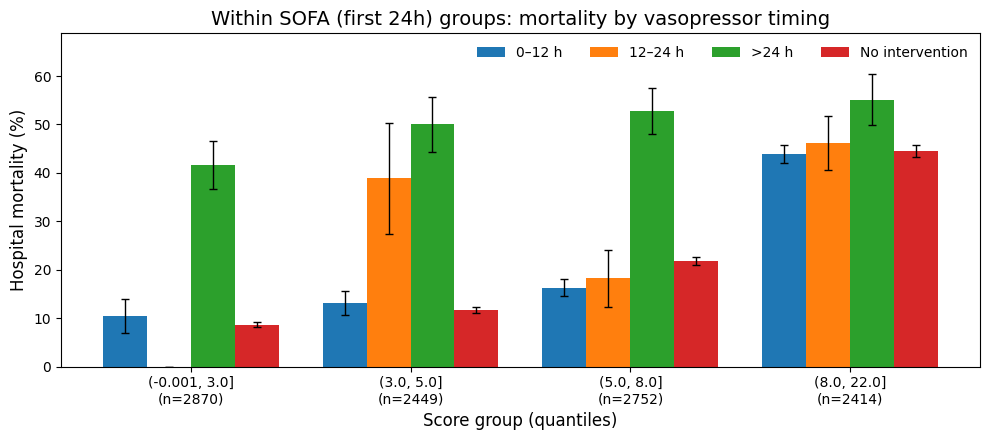

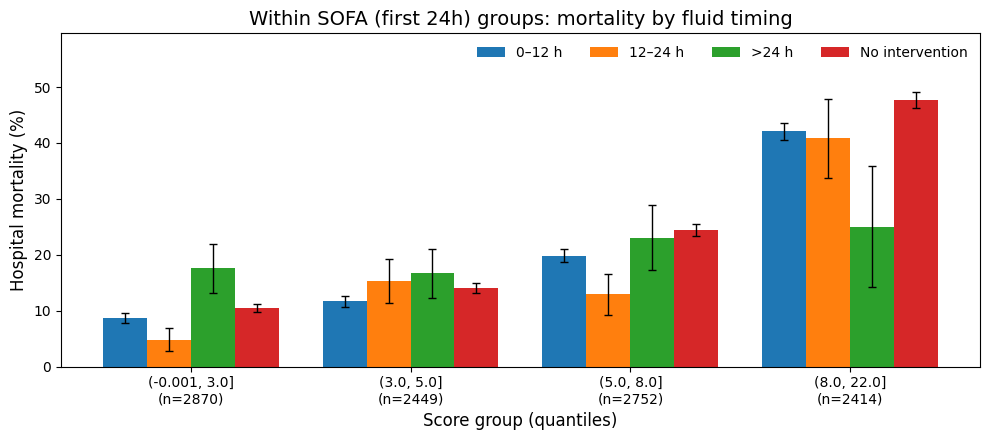

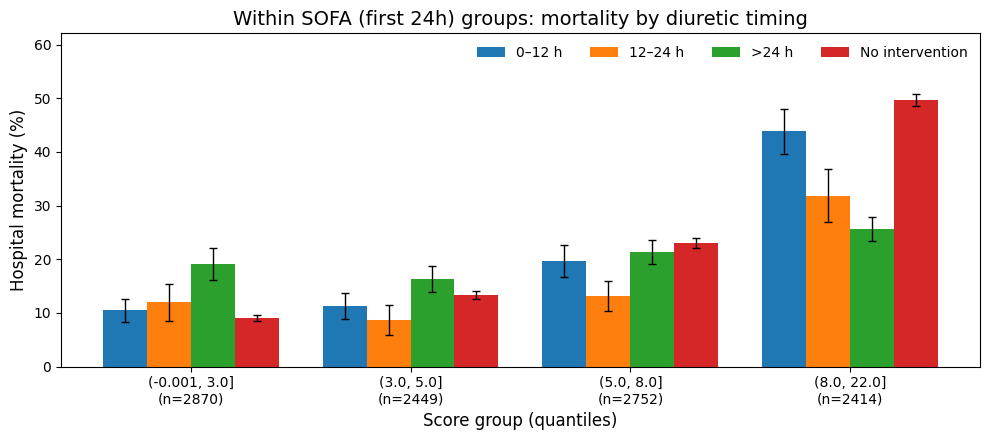

In [51]:
fig1 = plot_mortality_by_timing_within_score_bins(
    stats_sofa_vaso,
    score_bin_col="sofa_bin",
    timing_col="vaso_timing",
    title="Within SOFA (first 24h) groups: mortality by vasopressor timing"
)
plt.show()

fig2 = plot_mortality_by_timing_within_score_bins(
    stats_sofa_fluid,
    score_bin_col="sofa_bin",
    timing_col="fluid_timing",
    title="Within SOFA (first 24h) groups: mortality by fluid timing"
)
plt.show()

fig3 = plot_mortality_by_timing_within_score_bins(
    stats_sofa_diur,
    score_bin_col="sofa_bin",
    timing_col="diuretic_timing",
    title="Within SOFA (first 24h) groups: mortality by diuretic timing"
)
plt.show()


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([score_bin_col, timing_col])
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg["bin_total"] = agg.groupby(score_bin_col)["n"].transform("sum")


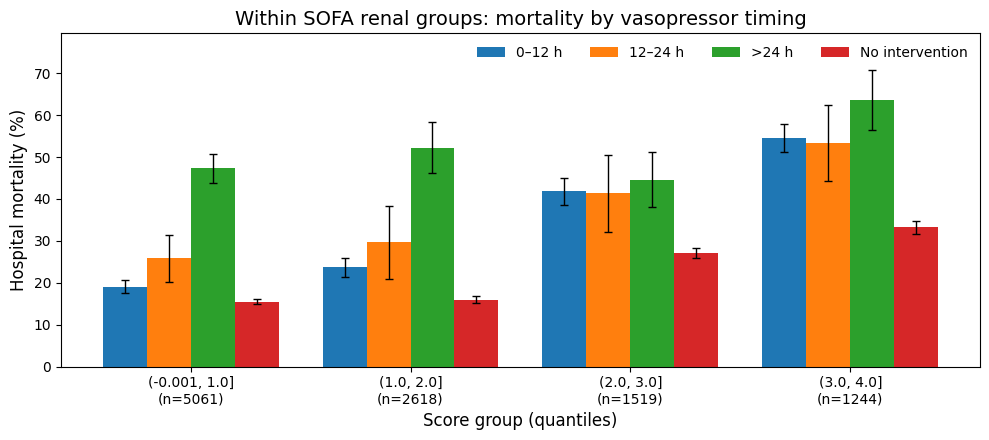

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([score_bin_col, timing_col])
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg["bin_total"] = agg.groupby(score_bin_col)["n"].transform("sum")


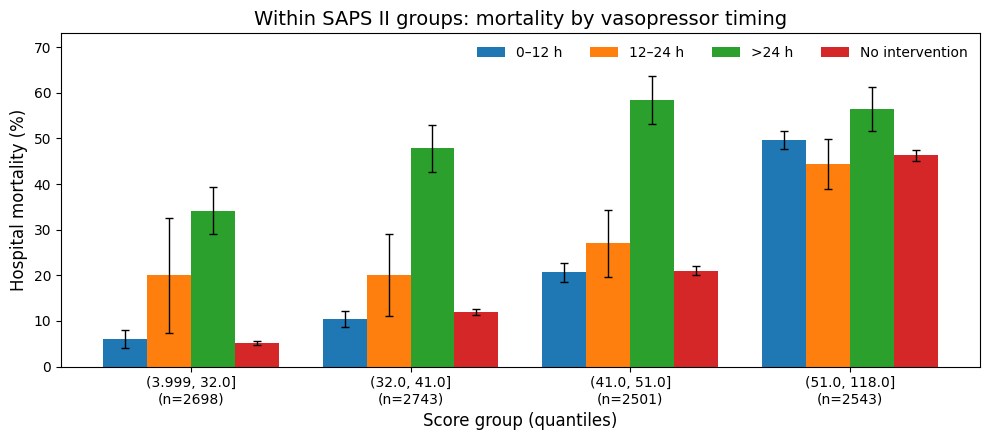

In [52]:
stats_renal_vaso = score_group_timing_stats(df4, "sofa_renal_bin", "vaso_timing")
plot_mortality_by_timing_within_score_bins(stats_renal_vaso, "sofa_renal_bin", "vaso_timing",
                                           "Within SOFA renal groups: mortality by vasopressor timing"); plt.show()

stats_saps_vaso = score_group_timing_stats(df4, "sapsii_bin", "vaso_timing")
plot_mortality_by_timing_within_score_bins(stats_saps_vaso, "sapsii_bin", "vaso_timing",
                                           "Within SAPS II groups: mortality by vasopressor timing"); plt.show()


In [53]:
import pandas as pd
import numpy as np
from src.db import q

def first_intervention_timing(
    df,
    patterns,
    label,
):
    """
    Adds two columns:
      - first_<label>_hours
      - first_<label>_timing  ∈ {0–12 h, 12–24 h, >24 h, No intervention}
    """

    where = " OR ".join([f"LOWER(di.label) LIKE '{p}'" for p in patterns])

    ev = q(f"""
        SELECT ie.icustay_id, ie.starttime
        FROM inputevents_mv ie
        JOIN d_items di ON ie.itemid = di.itemid
        WHERE {where}
    """)

    ev = ev.merge(
        df[["icustay_id", "intime"]],
        on="icustay_id",
        how="inner"
    ).dropna(subset=["starttime", "intime"])

    ev["hours_since_icu"] = (
        ev["starttime"] - ev["intime"]
    ).dt.total_seconds() / 3600

    ev = ev[ev["hours_since_icu"] >= 0]

    first_ev = (
        ev.sort_values(["icustay_id", "hours_since_icu"])
          .groupby("icustay_id", as_index=False)
          .first()[["icustay_id", "hours_since_icu"]]
    )

    out = df.merge(first_ev, on="icustay_id", how="left")

    timing_col = f"first_{label}_timing"
    hours_col = f"first_{label}_hours"

    out[hours_col] = out["hours_since_icu"]

    out[timing_col] = np.select(
        [
            out[hours_col].between(0, 12, inclusive="left"),
            out[hours_col].between(12, 24, inclusive="left"),
            out[hours_col] > 24,
            out[hours_col].isna(),
        ],
        [
            "0–12 h",
            "12–24 h",
            ">24 h",
            "No intervention",
        ],
        default="Other",
    )

    out[timing_col] = pd.Categorical(
        out[timing_col],
        categories=["0–12 h", "12–24 h", ">24 h", "No intervention"],
        ordered=True
    )

    return out.drop(columns=["hours_since_icu"])


C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([score_bin_col, timing_col])
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg["bin_total"] = agg.groupby(score_bin_col)["n"].transform("sum")


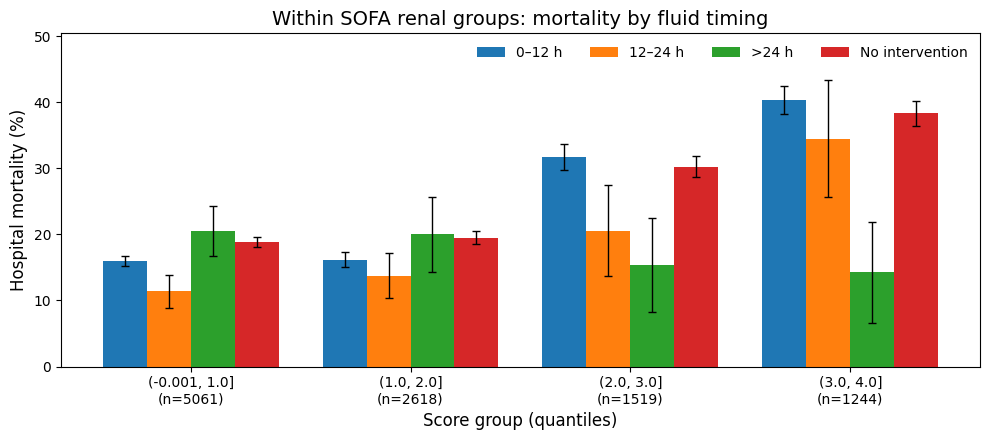

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([score_bin_col, timing_col])
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg["bin_total"] = agg.groupby(score_bin_col)["n"].transform("sum")


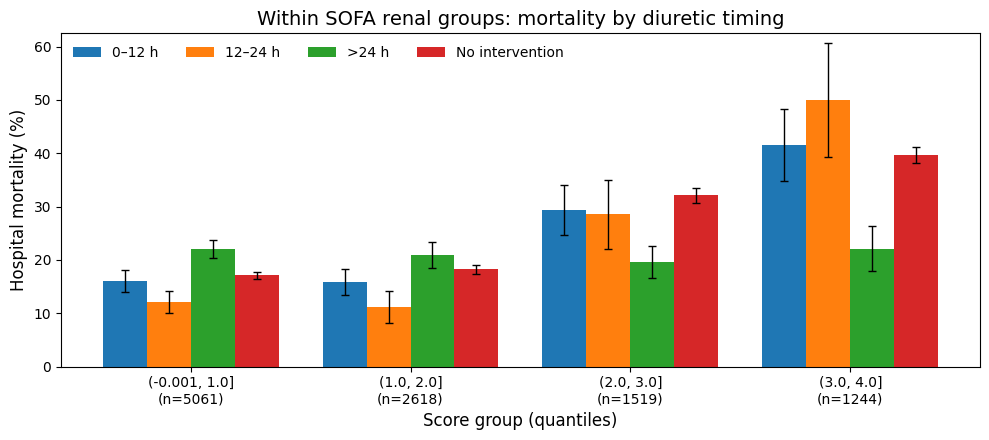

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([score_bin_col, timing_col])
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg["bin_total"] = agg.groupby(score_bin_col)["n"].transform("sum")


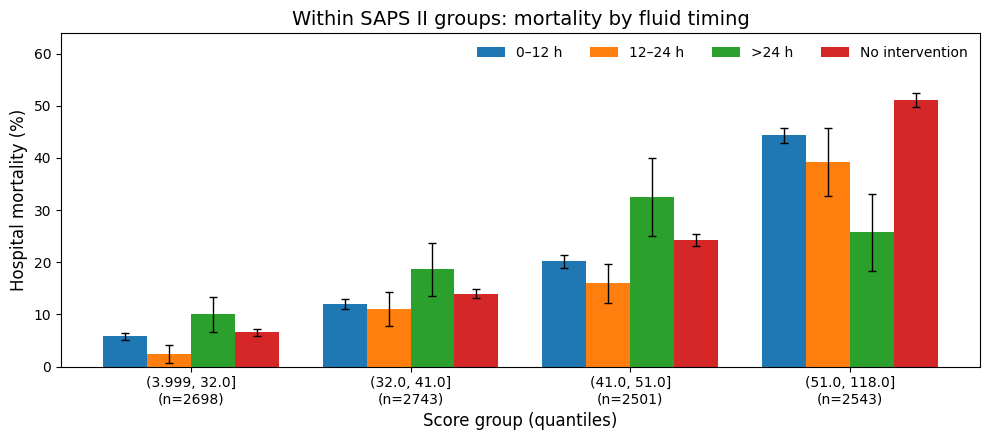

C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([score_bin_col, timing_col])
C:\Users\tobra\AppData\Local\Temp\ipykernel_17040\1865866853.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg["bin_total"] = agg.groupby(score_bin_col)["n"].transform("sum")


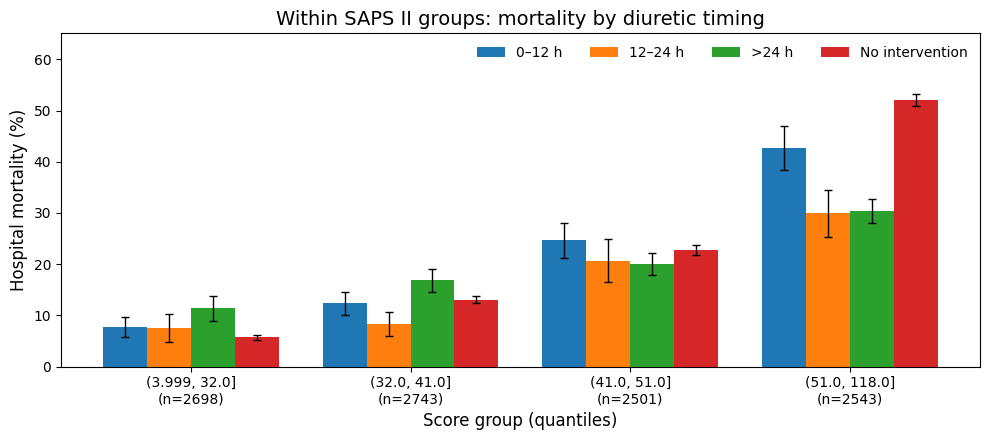

In [54]:
# --- SOFA renal bins: Fluids + Diuretics
stats_renal_fluid = score_group_timing_stats(df4, "sofa_renal_bin", "fluid_timing")
plot_mortality_by_timing_within_score_bins(
    stats_renal_fluid,
    "sofa_renal_bin",
    "fluid_timing",
    "Within SOFA renal groups: mortality by fluid timing"
); plt.show()

stats_renal_diur = score_group_timing_stats(df4, "sofa_renal_bin", "diuretic_timing")
plot_mortality_by_timing_within_score_bins(
    stats_renal_diur,
    "sofa_renal_bin",
    "diuretic_timing",
    "Within SOFA renal groups: mortality by diuretic timing"
); plt.show()


# --- SAPS II bins: Fluids + Diuretics
stats_saps_fluid = score_group_timing_stats(df4, "sapsii_bin", "fluid_timing")
plot_mortality_by_timing_within_score_bins(
    stats_saps_fluid,
    "sapsii_bin",
    "fluid_timing",
    "Within SAPS II groups: mortality by fluid timing"
); plt.show()

stats_saps_diur = score_group_timing_stats(df4, "sapsii_bin", "diuretic_timing")
plot_mortality_by_timing_within_score_bins(
    stats_saps_diur,
    "sapsii_bin",
    "diuretic_timing",
    "Within SAPS II groups: mortality by diuretic timing"
); plt.show()


In [55]:
def mean_scores_within_bins(
    df,
    score_bin_col,
    timing_col,
    score_cols=("sofa", "sofa_renal", "sapsii"),
):
    rows = []

    for b in df[score_bin_col].dropna().unique():
        sub_bin = df[df[score_bin_col] == b]

        for t in ["0–12 h", "12–24 h", ">24 h"]:
            sub = sub_bin[sub_bin[timing_col] == t]
            if sub.empty:
                continue

            row = {
                "Score bin": str(b),
                "Timing": t,
                "n": len(sub),
            }

            for sc in score_cols:
                med = sub[sc].mean()
                q1 = sub[sc].quantile(0.25)
                q3 = sub[sc].quantile(0.75)
                row[f"{sc} median (IQR)"] = f"{med:.1f} ({q1:.1f}–{q3:.1f})"

            rows.append(row)

    return pd.DataFrame(rows)


In [56]:
mean_sofa_vaso = mean_scores_within_bins(
    df4,
    score_bin_col="sofa_bin",
    timing_col="vaso_timing",
)

mean_sofa_vaso


,Score bin,Timing,n,sofa median (IQR),sofa_renal median (IQR),sapsii median (IQR)
0,"(5.0, 8.0]",0–12 h,437,7.0 (6.0–8.0),1.7 (1.0–2.0),44.9 (38.0–52.0)
1,"(5.0, 8.0]",12–24 h,44,7.3 (6.8–8.0),1.6 (1.0–3.0),48.0 (43.2–53.2)
2,"(5.0, 8.0]",>24 h,108,6.9 (6.0–8.0),1.8 (1.0–3.0),47.8 (38.8–57.0)
3,"(3.0, 5.0]",0–12 h,183,4.6 (4.0–5.0),1.0 (0.5–1.0),38.5 (32.0–46.0)
4,"(3.0, 5.0]",12–24 h,18,4.5 (4.0–5.0),1.2 (0.0–2.0),43.3 (34.2–56.8)
5,"(3.0, 5.0]",>24 h,78,4.6 (4.0–5.0),1.6 (1.0–3.0),38.4 (31.2–44.0)
6,"(-0.001, 3.0]",0–12 h,76,2.4 (2.0–3.0),0.7 (0.0–1.0),37.2 (32.0–43.0)
7,"(-0.001, 3.0]",12–24 h,6,2.5 (2.0–3.0),0.8 (1.0–1.0),37.8 (36.2–38.5)
8,"(-0.001, 3.0]",>24 h,101,2.1 (2.0–3.0),0.7 (0.0–1.0),33.9 (29.0–40.0)
9,"(8.0, 22.0]",0–12 h,723,12.1 (10.0–14.0),2.5 (1.5–4.0),59.3 (49.0–70.0)


use those valuesto show in graphik

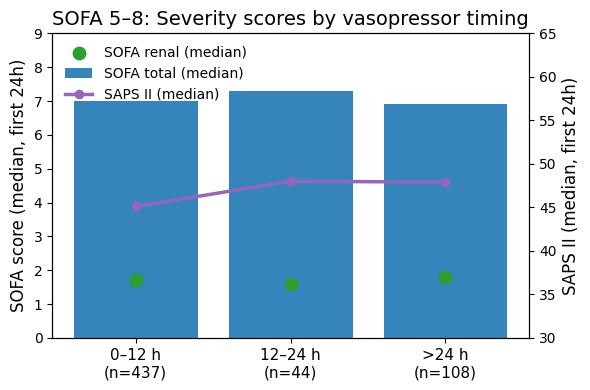

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- DataFrame direkt aus deinen Werten
plot_df = pd.DataFrame({
    "Timing": ["0–12 h", "12–24 h", ">24 h"],
    "n": [437, 44, 108],
    "sofa_median": [7.0, 7.3, 6.9],
    "sofa_renal_median": [1.7, 1.6, 1.8],
    "sapsii_median": [45.1, 48.0, 47.9],
})

x = np.arange(len(plot_df))

fig, ax1 = plt.subplots(figsize=(6, 4))

# --- SOFA total (bars)
ax1.bar(
    x,
    plot_df["sofa_median"],
    color="#1f77b4",
    alpha=0.9,
    label="SOFA total (median)"
)

# --- SOFA renal (points)
ax1.scatter(
    x,
    plot_df["sofa_renal_median"],
    color="#2ca02c",
    s=80,
    zorder=3,
    label="SOFA renal (median)"
)

ax1.set_ylabel("SOFA score (median, first 24h)", fontsize=12)
ax1.set_ylim(0, 9)

# --- SAPS II (line, second axis)
ax2 = ax1.twinx()
ax2.plot(
    x,
    plot_df["sapsii_median"],
    color="#9467bd",
    marker="o",
    linewidth=2.5,
    label="SAPS II (median)"
)
ax2.set_ylabel("SAPS II (median, first 24h)", fontsize=12)
ax2.set_ylim(30, 65)

# --- x labels with n
ax1.set_xticks(x)
ax1.set_xticklabels(
    [f"{t}\n(n={n})" for t, n in zip(plot_df["Timing"], plot_df["n"])],
    fontsize=11
)

# --- title
ax1.set_title(
    "SOFA 5–8: Severity scores by vasopressor timing",
    fontsize=14
)

# --- combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    loc="upper left"
)

plt.tight_layout()
plt.show()


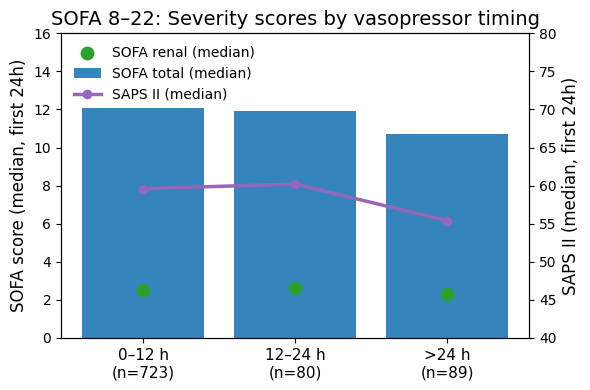

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Daten für SOFA 8–22
plot_df = pd.DataFrame({
    "Timing": ["0–12 h", "12–24 h", ">24 h"],
    "n": [723, 80, 89],
    "sofa_median": [12.1, 11.9, 10.7],
    "sofa_renal_median": [2.5, 2.6, 2.3],
    "sapsii_median": [59.6, 60.2, 55.4],
})

x = np.arange(len(plot_df))

fig, ax1 = plt.subplots(figsize=(6, 4))

# --- SOFA total (bars)
ax1.bar(
    x,
    plot_df["sofa_median"],
    color="#1f77b4",
    alpha=0.9,
    label="SOFA total (median)"
)

# --- SOFA renal (points)
ax1.scatter(
    x,
    plot_df["sofa_renal_median"],
    color="#2ca02c",
    s=80,
    zorder=3,
    label="SOFA renal (median)"
)

ax1.set_ylabel("SOFA score (median, first 24h)", fontsize=12)
ax1.set_ylim(0, 16)

# --- SAPS II (line, second axis)
ax2 = ax1.twinx()
ax2.plot(
    x,
    plot_df["sapsii_median"],
    color="#9467bd",
    marker="o",
    linewidth=2.5,
    label="SAPS II (median)"
)
ax2.set_ylabel("SAPS II (median, first 24h)", fontsize=12)
ax2.set_ylim(40, 80)

# --- x labels with n
ax1.set_xticks(x)
ax1.set_xticklabels(
    [f"{t}\n(n={n})" for t, n in zip(plot_df["Timing"], plot_df["n"])],
    fontsize=11
)

# --- title
ax1.set_title(
    "SOFA 8–22: Severity scores by vasopressor timing",
    fontsize=14
)

# --- combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    frameon=False,
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

df_test = df4.copy()

# Late vasopressor indicator
df_test["vaso_late"] = (
    df_test["vaso_timing"] == ">24 h"
).astype(int)

# Early (0–24 h) indicator
df_test["vaso_early"] = (
    df_test["vaso_timing"].isin(["0–12 h", "12–24 h"])
).astype(int)


In [ ]:
from scipy.stats import chi2_contingency, fisher_exact

def test_late_vs_early_by_score_bin(
    df,
    score_bin_col,
    outcome_col="hospital_mortality"
):
    results = []

    for b in df[score_bin_col].dropna().unique():
        sub = df[df[score_bin_col] == b]

        # only early vs late
        sub = sub[sub["vaso_timing"].isin(["0–12 h", "12–24 h", ">24 h"])]

        if sub.empty:
            continue

        table = pd.crosstab(
            sub["vaso_late"],
            sub[outcome_col]
        )

        # ensure 2x2
        if table.shape != (2, 2):
            continue

        n_late = table.loc[1].sum()
        n_early = table.loc[0].sum()

        mort_late = table.loc[1, 1] / n_late if n_late > 0 else np.nan
        mort_early = table.loc[0, 1] / n_early if n_early > 0 else np.nan

        # choose test
        if (table.values < 5).any():
            _, p = fisher_exact(table)
            test = "Fisher"
        else:
            _, p, _, _ = chi2_contingency(table)
            test = "Chi-square"

        results.append({
            "Score bin": str(b),
            "n early (≤24h)": n_early,
            "n late (>24h)": n_late,
            "Mortality early": mort_early * 100,
            "Mortality late": mort_late * 100,
            "Δ mortality (late−early)": (mort_late - mort_early) * 100,
            "p value": p,
            "Test": test,
        })

    return pd.DataFrame(results)


In [ ]:
test_sofa_vaso = test_late_vs_early_by_score_bin(
    df_test,
    score_bin_col="sofa_bin"
)

test_sofa_vaso


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.multitest import multipletests

def per_bin_effects(
    df,
    score_bin_col="sofa_bin",
    timing_col="vaso_timing",
    outcome_col="hospital_mortality",
    early_levels=("0–12 h", "12–24 h"),
    late_level=">24 h",
):
    rows = []

    bins = [b for b in df[score_bin_col].dropna().unique()]
    bins = sorted(bins, key=lambda x: str(x))

    for b in bins:
        sub = df[df[score_bin_col] == b].copy()
        sub = sub[sub[timing_col].isin(list(early_levels) + [late_level])].copy()
        if sub.empty:
            continue

        sub["late"] = (sub[timing_col] == late_level).astype(int)
        y = pd.to_numeric(sub[outcome_col], errors="coerce").astype("Int64")

        # 2x2 counts: rows late(1)/early(0), cols death(1)/survive(0)
        tab = pd.crosstab(sub["late"], y).reindex(index=[0,1], columns=[0,1], fill_value=0)

        # cells
        early_surv = int(tab.loc[0, 0]); early_death = int(tab.loc[0, 1])
        late_surv  = int(tab.loc[1, 0]); late_death  = int(tab.loc[1, 1])

        n_early = early_surv + early_death
        n_late  = late_surv + late_death
        if n_early == 0 or n_late == 0:
            continue

        risk_early = early_death / n_early
        risk_late  = late_death / n_late
        rd = risk_late - risk_early

        # Effect sizes + CI via Table2x2 (Woolf log-OR / log-RR; RD CI via normal approx not in Table2x2)
        t22 = Table2x2([[late_death, late_surv],[early_death, early_surv]])
        or_ = t22.oddsratio
        or_ci = t22.oddsratio_confint()     # 95% CI
        rr_ = t22.riskratio
        rr_ci = t22.riskratio_confint()

        # RD 95% CI (Newcombe-style is best; statsmodels has for 2 indep proportions)
        from statsmodels.stats.proportion import confint_proportions_2indep
        rd_ci = confint_proportions_2indep(
            late_death, n_late,
            early_death, n_early,
            method="newcomb"
        )

        # p-value: use Fisher if any expected <5 else chi-square
        chi2_ok = True
        try:
            _, p_chi, _, expected = chi2_contingency([[late_death, late_surv],[early_death, early_surv]])
            if (expected < 5).any():
                chi2_ok = False
        except:
            chi2_ok = False

        if chi2_ok:
            p = p_chi
            test = "Chi-square"
        else:
            _, p = fisher_exact([[late_death, late_surv],[early_death, early_surv]])
            test = "Fisher exact"

        rows.append({
            "Score bin": str(b),
            "early_death": early_death, "early_surv": early_surv, "n_early": n_early,
            "late_death": late_death, "late_surv": late_surv, "n_late": n_late,
            "risk_early_%": 100*risk_early,
            "risk_late_%": 100*risk_late,
            "RD_%": 100*rd,
            "RD_CI_low_%": 100*rd_ci[0],
            "RD_CI_high_%": 100*rd_ci[1],
            "RR": rr_, "RR_CI_low": rr_ci[0], "RR_CI_high": rr_ci[1],
            "OR": or_, "OR_CI_low": or_ci[0], "OR_CI_high": or_ci[1],
            "p": p,
            "test": test
        })

    res = pd.DataFrame(rows)

    # multiple-testing correction across bins (FDR/BH)
    if not res.empty:
        res["p_fdr_bh"] = multipletests(res["p"].values, method="fdr_bh")[1]

    # nice ordering for display
    return res.sort_values("Score bin").reset_index(drop=True)

res = per_bin_effects(df_test, score_bin_col="sofa_bin", timing_col="vaso_timing")
res


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

res = test_sofa_vaso.copy().sort_values("Score bin")

fig, ax = plt.subplots(figsize=(6.5, 4))

ax.bar(res["Score bin"], res["Δ mortality (late−early)"])

# p-value Sterne
def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

for i, row in res.reset_index(drop=True).iterrows():
    ax.text(i, row["Δ mortality (late−early)"] + 1.0,
            stars(row["p value"]),
            ha="center", va="bottom", fontsize=14)

ax.set_ylabel("Δ Mortality (Late − Early), percentage points", fontsize=12)
ax.set_title("Vasopressors: Excess mortality with late initiation", fontsize=14)
ax.tick_params(axis="x", labelrotation=0)
plt.tight_layout()
plt.show()



In [ ]:
test_renal_vaso = test_late_vs_early_by_score_bin(
    df_test,
    score_bin_col="sofa_renal_bin"
)

test_saps_vaso = test_late_vs_early_by_score_bin(
    df_test,
    score_bin_col="sapsii_bin"
)
test_renal_vaso_2 = test_late

test_renal_vaso, test_saps_vaso


In [ ]:
import statsmodels.formula.api as smf

# nur Patienten mit Vasopressoren
df_lr = df_test[df_test["vaso_timing"].isin(["0–12 h", "12–24 h", ">24 h"])].copy()

df_lr["vaso_late"] = (df_lr["vaso_timing"] == ">24 h").astype(int)

model = smf.logit(
    "hospital_mortality ~ vaso_late + sofa + vaso_late:sofa",
    data=df_lr
).fit()

model.summary()


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

def fmt_p(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

def choose_test_2x2(tab):
    # tab is 2x2 numpy array [[a,b],[c,d]]
    try:
        _, p_chi, _, expected = chi2_contingency(tab)
        if (expected < 5).any():
            _, p = fisher_exact(tab)
            return p, "Fisher exact"
        return p_chi, "Chi-square"
    except Exception:
        _, p = fisher_exact(tab)
        return p, "Fisher exact"


In [ ]:
def stratified_binary_outcome_table(
    df,
    score_bin_col,
    timing_col,
    group_a_levels,
    group_b_levels,
    outcome_col="hospital_mortality",
    label_a="A",
    label_b="B",
):
    rows = []

    bins = df[score_bin_col].dropna().unique()
    bins = sorted(bins, key=lambda x: str(x))

    for b in bins:
        sub = df[df[score_bin_col] == b].copy()
        sub = sub[sub[timing_col].isin(list(group_a_levels) + list(group_b_levels))].copy()
        if sub.empty:
            continue

        sub["grp"] = np.where(sub[timing_col].isin(group_b_levels), "B", "A")
        y = pd.to_numeric(sub[outcome_col], errors="coerce").fillna(0).astype(int)

        n_a = int((sub["grp"] == "A").sum())
        n_b = int((sub["grp"] == "B").sum())
        if n_a == 0 or n_b == 0:
            continue

        deaths_a = int(y[sub["grp"] == "A"].sum())
        deaths_b = int(y[sub["grp"] == "B"].sum())

        mort_a = 100 * deaths_a / n_a
        mort_b = 100 * deaths_b / n_b
        delta = mort_b - mort_a  # percentage points

        alive_a = n_a - deaths_a
        alive_b = n_b - deaths_b
        tab = np.array([[alive_a, deaths_a], [alive_b, deaths_b]])

        p, test = choose_test_2x2(tab)

        rows.append({
            "Score bin": str(b),
            f"n {label_a}": n_a,
            f"n {label_b}": n_b,
            f"Mortality {label_a} (%)": mort_a,
            f"Mortality {label_b} (%)": mort_b,
            "Δ Mortality (pp)": delta,
            "p value": p,
            "Test": test,
        })

    out = pd.DataFrame(rows)

    # ---- Slide-friendly formatting
    if out.empty:
        return out

    for col in out.columns:
        if "Mortality" in col or col == "Δ Mortality (pp)":
            out[col] = out[col].astype(float).round(1)

    out["p value"] = out["p value"].map(fmt_p)

    return out


In [ ]:
tab_early_vs_late = stratified_binary_outcome_table(
    df_test,                       # oder df4/df3, solange sofa_bin + vaso_timing + hospital_mortality drin ist
    score_bin_col="sofa_bin",
    timing_col="vaso_timing",
    group_a_levels=["0–12 h", "12–24 h"],   # Early
    group_b_levels=[">24 h"],              # Late
    label_a="Early (≤24h)",
    label_b="Late (>24h)",
)

tab_early_vs_late


In [61]:
tab_late_vs_never = stratified_binary_outcome_table(
    df_test,
    score_bin_col="sofa_bin",
    timing_col="vaso_timing",
    group_a_levels=["No intervention"],
    group_b_levels=[">24 h"],
    label_a="Never",
    label_b="Late (>24h)",
)

tab_late_vs_never


NameError: name 'stratified_binary_outcome_table' is not defined

In [60]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

def sofa_renal_late_vs_never(
    df,
    renal_bin_col="sofa_renal_bin",
    timing_col="vaso_timing",
    outcome_col="hospital_mortality",
):
    rows = []

    bins = sorted(df[renal_bin_col].dropna().unique(), key=lambda x: str(x))

    for b in bins:
        sub = df[df[renal_bin_col] == b].copy()
        sub = sub[sub[timing_col].isin(["No intervention", ">24 h"])].copy()
        if sub.empty:
            continue

        sub["grp"] = np.where(sub[timing_col] == ">24 h", "Late", "Never")
        y = pd.to_numeric(sub[outcome_col], errors="coerce").fillna(0).astype(int)

        n_never = int((sub["grp"] == "Never").sum())
        n_late  = int((sub["grp"] == "Late").sum())
        if n_never == 0 or n_late == 0:
            continue

        d_never = int(y[sub["grp"] == "Never"].sum())
        d_late  = int(y[sub["grp"] == "Late"].sum())

        mort_never = 100 * d_never / n_never
        mort_late  = 100 * d_late  / n_late
        delta = mort_late - mort_never

        # 2x2 table: rows Never/Late, cols Alive/Dead
        tab = np.array([
            [n_never - d_never, d_never],
            [n_late  - d_late,  d_late],
        ])

        # automatic test choice
        try:
            _, p_chi, _, exp = chi2_contingency(tab)
            if (exp < 5).any():
                _, p = fisher_exact(tab)
                test = "Fisher exact"
            else:
                p = p_chi
                test = "Chi-square"
        except:
            _, p = fisher_exact(tab)
            test = "Fisher exact"

        rows.append({
            "SOFA renal score bin": str(b),
            "Never n": n_never,
            "Late n": n_late,
            "Mortality Never (%)": round(mort_never, 1),
            "Mortality Late (%)": round(mort_late, 1),
            "Δ Mortality (pp)": round(delta, 1),
            "p value": "<0.001" if p < 0.001 else f"{p:.3f}",
            "Test": test,
        })

    return pd.DataFrame(rows)


In [ ]:
tab_renal_late_vs_never = sofa_renal_late_vs_never(df_test)
tab_renal_late_vs_never


In [ ]:
import statsmodels.formula.api as smf

df_simple = df_test[
    df_test["vaso_timing"].isin(["0–12 h", "12–24 h", ">24 h"])
].copy()

df_simple["vaso_late"] = (df_simple["vaso_timing"] == ">24 h").astype(int)

model_simple = smf.logit(
    "hospital_mortality ~ vaso_late + sofa",
    data=df_simple
).fit()

model_simple.summary()


In [ ]:
import statsmodels.formula.api as smf

# nur Late vs Never
df_late_never = df_test[
    df_test["vaso_timing"].isin([">24 h", "No intervention"])
].copy()

# Binary indicator: Late = 1, Never = 0
df_late_never["vaso_late"] = (df_late_never["vaso_timing"] == ">24 h").astype(int)

model_late_vs_never = smf.logit(
    "hospital_mortality ~ vaso_late + sofa",
    data=df_late_never
).fit()

model_late_vs_never.summary()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SOFA range
sofa_vals = np.arange(0, 20)

# design matrix
pred_df = pd.DataFrame({
    "sofa": np.tile(sofa_vals, 2),
    "vaso_late": np.repeat([0, 1], len(sofa_vals)),
})

# predict probabilities
pred_df["mortality"] = model_simple.predict(pred_df)

# plot
plt.figure(figsize=(7,5))
for k, g in pred_df.groupby("vaso_late"):
    label = "Early (≤24 h)" if k == 0 else "Late (>24 h)"
    plt.plot(g["sofa"], 100*g["mortality"], label=label, linewidth=3)

plt.xlabel("SOFA score (first 24h)")
plt.ylabel("Predicted hospital mortality (%)")
plt.title("Adjusted mortality by vasopressor timing")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
pred_df2 = pd.DataFrame({
    "sofa": np.tile(sofa_vals, 2),
    "vaso_late": np.repeat([0, 1], len(sofa_vals)),
})

pred_df2["mortality"] = model_late_vs_never.predict(pred_df2)

plt.figure(figsize=(7,5))
for k, g in pred_df2.groupby("vaso_late"):
    label = "Never" if k == 0 else "Late (>24 h)"
    plt.plot(g["sofa"], 100*g["mortality"], label=label, linewidth=3)

plt.xlabel("SOFA score (first 24h)")
plt.ylabel("Predicted hospital mortality (%)")
plt.title("Adjusted mortality: late vs never vasopressors")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Late vs Early (≤24h) subset
df_evle = df_test[df_test["vaso_timing"].isin(["0–12 h", "12–24 h", ">24 h"])].copy()
df_evle["vaso_late"] = (df_evle["vaso_timing"] == ">24 h").astype(int)

# keep only valid mortality
df_evle["hospital_mortality"] = pd.to_numeric(df_evle["hospital_mortality"], errors="coerce")
df_evle = df_evle.dropna(subset=["hospital_mortality", "sofa"])
df_evle["hospital_mortality"] = df_evle["hospital_mortality"].astype(int)


In [ ]:
def fit_effect_modification_logit(df, subgroup_col, ref=None):
    d = df.copy()

    # sanitize subgroup
    d = d.dropna(subset=[subgroup_col]).copy()

    # optional: set reference category
    if ref is not None:
        d[subgroup_col] = pd.Categorical(d[subgroup_col], categories=[ref] + [c for c in d[subgroup_col].unique() if c != ref])

    # Main effects + interaction
    # Outcome: hospital_mortality
    # Adjust: sofa
    # Exposure: vaso_late
    formula = f"hospital_mortality ~ vaso_late + sofa + C({subgroup_col}) + vaso_late:C({subgroup_col})"
    m = smf.logit(formula, data=d).fit(disp=0)
    return m

def interaction_pvalues(model):
    # pull only interaction terms (vaso_late:C(...))
    pv = model.pvalues
    inter = pv[pv.index.str.contains("vaso_late:C(", regex=False)]
    return inter.sort_values()


In [ ]:
m_gender = fit_effect_modification_logit(df_evle, "gender")
print(m_gender.summary())
print("\nInteraction p-values (vaso_late × gender):")
print(interaction_pvalues(m_gender))


In [ ]:
m_eth = fit_effect_modification_logit(df_evle, "ethnicity_grp", ref="White")
print(m_eth.summary())
print("\nInteraction p-values (vaso_late × ethnicity_grp):")
print(interaction_pvalues(m_eth))


In [ ]:
import numpy as np

def subgroup_specific_or(df, subgroup_col):
    out_rows = []
    for g, sub in df.dropna(subset=[subgroup_col]).groupby(subgroup_col):
        # simple adjusted model within subgroup
        m = smf.logit("hospital_mortality ~ vaso_late + sofa", data=sub).fit(disp=0)

        b = m.params["vaso_late"]
        lo, hi = m.conf_int().loc["vaso_late"].tolist()
        out_rows.append({
            subgroup_col: g,
            "n": len(sub),
            "OR (Late vs Early)": float(np.exp(b)),
            "CI low": float(np.exp(lo)),
            "CI high": float(np.exp(hi)),
            "p": float(m.pvalues["vaso_late"]),
        })
    res = pd.DataFrame(out_rows).sort_values(subgroup_col)
    res["p"] = res["p"].map(lambda x: "<0.001" if x < 0.001 else f"{x:.3f}")
    for c in ["OR (Late vs Early)", "CI low", "CI high"]:
        res[c] = res[c].map(lambda x: round(x, 2))
    return res

tab_gender = subgroup_specific_or(df_evle, "gender")
tab_eth = subgroup_specific_or(df_evle, "ethnicity_grp")

tab_gender, tab_eth


In [ ]:
tab_gender_expl = (
    df_test[df_test["vaso_timing"].isin(["0–12 h", "12–24 h", ">24 h"])]
    .groupby(["gender", "vaso_timing"])
    .agg(
        n=("hospital_mortality", "size"),
        mortality=("hospital_mortality", "mean"),
    )
    .reset_index()
)

tab_gender_expl["mortality"] = 100 * tab_gender_expl["mortality"]
tab_gender_expl


In [ ]:
def delta_late_early(df, gender):
    sub = df[df["gender"] == gender]
    early = sub[sub["vaso_timing"].isin(["0–12 h", "12–24 h"])]
    late  = sub[sub["vaso_timing"] == ">24 h"]

    return {
        "Gender": gender,
        "Early mortality (%)": 100 * early["hospital_mortality"].mean(),
        "Late mortality (%)": 100 * late["hospital_mortality"].mean(),
        "Δ mortality (pp)": 100 * (late["hospital_mortality"].mean() - early["hospital_mortality"].mean()),
    }

pd.DataFrame([
    delta_late_early(df_test, "M"),
    delta_late_early(df_test, "F"),
])


In [ ]:
import pandas as pd
import numpy as np

# Late vs Early subset
df_bd = df_test[df_test["vaso_timing"].isin(["0–12 h", "12–24 h", ">24 h"])].copy()
df_bd["late"] = (df_bd["vaso_timing"] == ">24 h").astype(int)

# keep needed cols
df_bd = df_bd[["gender", "late", "hospital_mortality"]].dropna()
df_bd["hospital_mortality"] = df_bd["hospital_mortality"].astype(int)


In [ ]:
tables = {}

for g in ["M", "F"]:
    sub = df_bd[df_bd["gender"] == g]
    tab = pd.crosstab(
        sub["late"],
        sub["hospital_mortality"]
    )
    # ensure shape [[alive, dead], [alive, dead]]
    tab = tab.reindex(index=[0,1], columns=[0,1], fill_value=0)
    tables[g] = tab.values

tables


In [ ]:
from statsmodels.stats.contingency_tables import StratifiedTable

st = StratifiedTable(list(tables.values()))
bd_res = st.test_equal_odds()

print(bd_res)


In [ ]:
import pandas as pd
import numpy as np

# Late vs Early only
df_bd_eth = df_test[df_test["vaso_timing"].isin(["0–12 h", "12–24 h", ">24 h"])].copy()
df_bd_eth["late"] = (df_bd_eth["vaso_timing"] == ">24 h").astype(int)

# keep only major ethnic groups
valid_eth = ["White", "Black", "Other"]
df_bd_eth = df_bd_eth[df_bd_eth["ethnicity_grp"].isin(valid_eth)]

# clean outcome
df_bd_eth = df_bd_eth[["ethnicity_grp", "late", "hospital_mortality"]].dropna()
df_bd_eth["hospital_mortality"] = df_bd_eth["hospital_mortality"].astype(int)


In [ ]:
tables_eth = {}

for e in valid_eth:
    sub = df_bd_eth[df_bd_eth["ethnicity_grp"] == e]

    tab = pd.crosstab(
        sub["late"],
        sub["hospital_mortality"]
    )

    # enforce shape: rows = late(0/1), cols = alive/dead(0/1)
    tab = tab.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    tables_eth[e] = tab.values

tables_eth


In [ ]:
from statsmodels.stats.contingency_tables import StratifiedTable

st_eth = StratifiedTable(list(tables_eth.values()))
bd_eth = st_eth.test_equal_odds()

print(bd_eth)


In [ ]:
# Early only
df_base = df_test[
    df_test["vaso_timing"].isin(["0–12 h", "12–24 h"])
].copy()

tab_base_eth = (
    df_base
    .groupby("ethnicity_grp")
    .agg(
        n=("hospital_mortality", "size"),
        mortality=("hospital_mortality", "mean")
    )
    .reset_index()
)

tab_base_eth["mortality (%)"] = 100 * tab_base_eth["mortality"]
tab_base_eth = tab_base_eth.sort_values("mortality (%)")

tab_base_eth


In [ ]:
from scipy.stats import chi2_contingency

tab = pd.crosstab(
    df_base["ethnicity_grp"],
    df_base["hospital_mortality"]
)

chi2, p, _, _ = chi2_contingency(tab)

print(chi2, p)


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

df_bw = df_test[
    (df_test["vaso_timing"].isin(["0–12 h", "12–24 h"])) &
    (df_test["ethnicity_grp"].isin(["Black", "White"]))
].copy()

df_bw["hospital_mortality"] = df_bw["hospital_mortality"].astype(int)


In [ ]:
# Late vasopressors only
df_late = df[
    df_test["vaso_timing"] == ">24 h"
].copy()

# Median + IQR
median_time = df_late["hours_since_icu"].median()
q1 = df_late["hours_since_icu"].quantile(0.25)
q3 = df_late["hours_since_icu"].quantile(0.75)

median_time, q1, q3


In [ ]:
tab_bw = pd.crosstab(
    df_bw["ethnicity_grp"],
    df_bw["hospital_mortality"]
)

tab_bw


In [ ]:
# expected counts prüfen
chi2, p_chi, _, expected = chi2_contingency(tab_bw)

if (expected < 5).any():
    _, p = fisher_exact(tab_bw)
    test = "Fisher exact"
else:
    p = p_chi
    test = "Chi-square"

p, test


In [ ]:
mort_bw = (
    df_bw
    .groupby("ethnicity_grp")
    .agg(
        n=("hospital_mortality", "size"),
        mortality=("hospital_mortality", "mean")
    )
    .reset_index()
)

mort_bw["mortality (%)"] = 100 * mort_bw["mortality"]
mort_bw


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

df_mw = df_test[
    df_test["vaso_timing"].isin(["0–12 h", "12–24 h"])
].copy()

df_mw["hospital_mortality"] = df_mw["hospital_mortality"].astype(int)


In [ ]:
tab_mw = pd.crosstab(
    df_mw["gender"],
    df_mw["hospital_mortality"]
)

tab_mw


In [ ]:
chi2, p_chi, _, expected = chi2_contingency(tab_mw)

if (expected < 5).any():
    _, p = fisher_exact(tab_mw)
    test = "Fisher exact"
else:
    p = p_chi
    test = "Chi-square"

p, test


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

df_early = df[
    df_test["vaso_timing"].isin(["0–12 h", "12–24 h"])
]

tab_mw = pd.crosstab(
    df_early["gender"],
    df_early["hospital_mortality"]
)

chi2, p_mw_baseline, _, _ = chi2_contingency(tab_mw)

p_mw_baseline


In [ ]:
df_early_bw = df_early[
    df_early["ethnicity_grp"].isin(["Black", "White"])
]

tab_bw = pd.crosstab(
    df_early_bw["ethnicity_grp"],
    df_early_bw["hospital_mortality"]
)

chi2, p_bw_baseline, _, _ = chi2_contingency(tab_bw)

p_bw_baseline


In [ ]:
df_timing = df[
    df_test["vaso_timing"].isin(["0–12 h", "12–24 h", ">24 h"])
].copy()

df_timing["late"] = (df_timing["vaso_timing"] == ">24 h").astype(int)

# Stratified 2x2 tables
tables_gender = []

for g in ["M", "F"]:
    sub = df_timing[df_timing["gender"] == g]
    tab = pd.crosstab(sub["late"], sub["hospital_mortality"])
    tab = tab.reindex(index=[0,1], columns=[0,1], fill_value=0)
    tables_gender.append(tab.values)

from statsmodels.stats.contingency_tables import StratifiedTable

st_gender = StratifiedTable(tables_gender)
p_gender_effect = st_gender.test_equal_odds().pvalue

p_gender_effect


In [ ]:
tables_eth = []

for e in ["White", "Black"]:
    sub = df_timing[df_timing["ethnicity_grp"] == e]
    tab = pd.crosstab(sub["late"], sub["hospital_mortality"])
    tab = tab.reindex(index=[0,1], columns=[0,1], fill_value=0)
    tables_eth.append(tab.values)

st_eth = StratifiedTable(tables_eth)
p_eth_effect = st_eth.test_equal_odds().pvalue

p_eth_effect


In [ ]:
import pandas as pd

df_tmp = df.copy()

# Zeit bis Tod in Stunden
df_tmp["hours_to_death"] = (
    df_tmp["deathtime"] - df_tmp["intime"]
).dt.total_seconds() / 3600

# Tod innerhalb 24h
df_tmp["death_within_24h"] = (
    (df_tmp["hospital_mortality"] == 1) &
    (df_tmp["hours_to_death"] >= 0) &
    (df_tmp["hours_to_death"] <= 24)
)

# Anzahl
n_deaths_24h = df_tmp["death_within_24h"].sum()

n_deaths_24h


In [ ]:
df_tmp = df.copy()

df_tmp["hours_to_death"] = (
    df_tmp["deathtime"] - df_tmp["intime"]
).dt.total_seconds() / 3600

df_early_death = df_tmp[
    (df_tmp["hospital_mortality"] == 1) &
    (df_tmp["hours_to_death"] >= 0) &
    (df_tmp["hours_to_death"] <= 24)
].copy()

len(df_early_death)


In [ ]:
interventions = [
    "any_vasopressor",
    "early_vasopressor",
]

intervention_summary = {}

for col in interventions:
    if col in df_early_death.columns:
        intervention_summary[col] = {
            "n": df_early_death[col].sum(),
            "pct": 100 * df_early_death[col].mean()
        }

pd.DataFrame(intervention_summary).T


looking after surviavalship biases 

In [ ]:
sofa_median = df_early_death["sofa"].median()
sofa_iqr = df_early_death["sofa"].quantile([0.25, 0.75])
sof_0_8 = df_early_death["sofa"].between(0, 8).sum()
sofa_median, sofa_iqr, sof_0_8


nearly no of them would be in our relevant group (sofa score 0-8) n = 49

In [ ]:
# Late vasopressors only
df_late = df[
    df["vaso_timing"] == ">24 h"
].copy()

# Median + IQR
median_time = df_late["hours_since_icu"].median()
q1 = df_late["hours_since_icu"].quantile(0.25)
q3 = df_late["hours_since_icu"].quantile(0.75)

median_time, q1, q3
